In [ ]:
import os
import numpy as np
import random
import collections
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image


In [ ]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # keep deterministic behavior where possible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

CHECKPOINTS_DIR = './checkpoints'
RESULTS_DIR = './results'
COMPARISON_DIR = './comparison'
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(COMPARISON_DIR, exist_ok=True)

BATCH_SIZE = 128
EPOCHS = 40
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Checkpoints dir: {CHECKPOINTS_DIR}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Comparison dir: {COMPARISON_DIR}")

In [ ]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [ ]:
# ==========================================
# PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

In [ ]:
data_iter = iter(train_loader)
batch = next(data_iter)

# A batch usually consists of features (images) and labels
# The structure depends on how your Dataset.__getitem__ is implemented
if isinstance(batch, list) or isinstance(batch, tuple):
    images, labels = batch
    print(f"Images shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
else:
    # If your dataloader returns a single item
    print(f"Batch shape: {batch.shape}")




In [ ]:
idx = min(60, len(images) - 1)

img = images[idx].numpy().reshape(28, 28)
if img.max() <= 1.0:
    img = img * 255.0
img = img.astype(np.uint8)

class_id = labels[idx].item()
class_names = list(full_train_dataset.classes) if hasattr(full_train_dataset, "classes") else CLASSES
class_name = class_names[class_id]

pil_img = Image.fromarray(img)

plt.figure(figsize=(3, 3))
plt.imshow(pil_img, cmap='gray')
plt.title(f"Class: {class_name} ({class_id})")
plt.axis('off')
plt.show()

In [ ]:
# ==========================================
# NORMALIZATION
# ==========================================

DATA_MEAN = full_train_dataset.x.mean().item()
DATA_STD = full_train_dataset.x.std().item() + 1e-8
print(f"DATA_MEAN={DATA_MEAN:.6f}, DATA_STD={DATA_STD:.6f}")

def normalize_batch(images):
    return (images.float() - DATA_MEAN) / DATA_STD

In [ ]:
# ==========================================
# TRAINING UTILS
# ==========================================

def train_one_epoch(model, train_loader, optimizer, criterion, device, scheduler=None):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    grad_sums = collections.defaultdict(float)
    grad_counts = collections.defaultdict(int)

    is_onecycle = isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR)

    for images, labels in train_loader:
        images = normalize_batch(images).to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        for name, parameter in model.named_parameters():
            if parameter.grad is not None and parameter.requires_grad:
                grad_norm = parameter.grad.detach().norm(2).item()
                grad_sums[name] += grad_norm
                grad_counts[name] += 1

        optimizer.step()
        if is_onecycle:
            scheduler.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (outputs.argmax(dim=1) == labels).sum().item()
        total_samples += labels.size(0)

    avg_grad_norms = {k: grad_sums[k] / max(1, grad_counts[k]) for k in grad_sums}
    return total_loss / total_samples, total_correct / total_samples, avg_grad_norms


def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = normalize_batch(images).to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            total_correct += (outputs.argmax(dim=1) == labels).sum().item()
            total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


def fit_model(
    model,
    model_name,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    scheduler=None,
    epochs=EPOCHS,
    verbose=True,
    save_best_path=None,
):
    history = {
        "model_name": model_name,
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
        "grad_norms": [],
    }

    best_val_acc, best_epoch = -1.0, -1

    is_onecycle = isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR)
    is_plateau = isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau)

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, grad_norms = train_one_epoch(
            model, train_loader, optimizer, criterion, device, scheduler=scheduler
        )
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        if scheduler is not None:
            if is_plateau:
                scheduler.step(val_acc)
            elif not is_onecycle:
                scheduler.step()

        lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(lr)
        history["grad_norms"].append(grad_norms)

        if val_acc > best_val_acc:
            best_val_acc, best_epoch = val_acc, epoch
            if save_best_path is not None:
                torch.save(model.state_dict(), save_best_path)

        if verbose:
            print(
                f"[{model_name}] Epoch {epoch:02d}/{epochs} | "
                f"Train: loss {train_loss:.4f}, acc {train_acc:.4f} | "
                f"Val: loss {val_loss:.4f}, acc {val_acc:.4f} | "
                f"LR: {lr:.6f} | Best Val: {best_val_acc:.4f} (ep {best_epoch})"
            )

    history["best_val_acc"] = best_val_acc
    history["best_epoch"] = best_epoch
    if save_best_path is not None:
        print(f"Best checkpoint saved: {save_best_path}")

    return history

In [ ]:
# ==========================================
# DIAGNOSTICS UTILS
# ==========================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_training_diagnostics(history, top_k_layers=10):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss vs Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs, history["val_acc"], label="Val Acc")
    axes[1].set_title("Accuracy vs Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, history["lr"], label="Learning Rate")
    axes[2].set_title("Learning Rate vs Epoch")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("LR")
    axes[2].set_yscale("log")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    grad_norms = history.get("grad_norms", [])
    if not grad_norms:
        return

    layer_names = sorted({name for epoch_dict in grad_norms for name in epoch_dict.keys()})
    mean_grad = {}
    for name in layer_names:
        values = [epoch_dict.get(name, np.nan) for epoch_dict in grad_norms]
        values = [v for v in values if not np.isnan(v)]
        mean_grad[name] = np.mean(values) if values else 0.0

    top_layers = sorted(mean_grad, key=mean_grad.get, reverse=True)[:top_k_layers]

    plt.figure(figsize=(12, 6))
    for name in top_layers:
        y = [epoch_dict.get(name, np.nan) for epoch_dict in grad_norms]
        plt.plot(epochs, y, label=name, alpha=0.85)

    plt.title(f"Gradient Norm Traverse (Top {top_k_layers} layers)")
    plt.xlabel("Epoch")
    plt.ylabel("Avg Grad L2 Norm")
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def get_predictions_and_labels(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = normalize_batch(images).to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    return np.concatenate(all_preds), np.concatenate(all_labels)


def plot_confusion_and_classwise(preds, labels, classes):
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
    plt.title("Confusion Matrix (Validation Set)")
    plt.tight_layout()
    plt.show()

    class_acc = cm.diagonal() / np.clip(cm.sum(axis=1), 1, None)
    print("Class-wise accuracy (worst to best):")
    for idx in np.argsort(class_acc):
        print(f"{classes[idx]:15s} : {class_acc[idx]:.3f}")

    return cm, class_acc


@torch.no_grad()
def collect_all_misclassified(model, val_loader, device):
    model.eval()
    misclassified = []

    for images, labels in val_loader:
        logits = model(normalize_batch(images).to(device))
        probs = torch.softmax(logits, dim=1).cpu()
        preds = torch.argmax(probs, dim=1)

        labels_cpu = labels.cpu()
        images_cpu = images.cpu()
        wrong_mask = preds != labels_cpu

        wrong_idx = torch.where(wrong_mask)[0].tolist()
        for idx_in_batch in wrong_idx:
            pred = int(preds[idx_in_batch].item())
            true = int(labels_cpu[idx_in_batch].item())
            misclassified.append({
                "true": true,
                "pred": pred,
                "conf": float(probs[idx_in_batch, pred].item()),
                "image": images_cpu[idx_in_batch].detach().clone(),
            })

    return misclassified


def show_misclassified_for_pair(misclassified, true_class, pred_class, classes, n=8):
    selected = [m for m in misclassified if m["true"] == true_class and m["pred"] == pred_class]
    if not selected:
        print(f"No samples for pair: {classes[true_class]} -> {classes[pred_class]}")
        return

    selected = sorted(selected, key=lambda x: x["conf"], reverse=True)[:n]
    cols = min(4, len(selected))
    rows = int(np.ceil(len(selected) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for axis, item in zip(axes, selected):
        img = item["image"].view(28, 28).numpy()
        axis.imshow(img, cmap="gray")
        axis.set_title(f"{classes[item['true']]} -> {classes[item['pred']]}\nconf={item['conf']:.2f}")
        axis.axis("off")

    for axis in axes[len(selected):]:
        axis.axis("off")

    plt.tight_layout()
    plt.show()


def show_top_misclassified_pairs(misclassified, classes, top_k_pairs=5, samples_per_pair=8):
    pair_counts = collections.Counter((m["true"], m["pred"]) for m in misclassified)
    if not pair_counts:
        print("No misclassified samples found.")
        return

    top_pairs = pair_counts.most_common(top_k_pairs)
    print("Top misclassified class pairs:")
    for (true_class, pred_class), count in top_pairs:
        print(f"{classes[true_class]} -> {classes[pred_class]} : {count}")
        show_misclassified_for_pair(
            misclassified,
            true_class=true_class,
            pred_class=pred_class,
            classes=classes,
            n=samples_per_pair,
        )


def run_diagnostics(model, history, val_loader, device, classes, top_k_layers=10, top_k_pairs=5, samples_per_pair=8):
    plot_training_diagnostics(history, top_k_layers=top_k_layers)

    preds, labels = get_predictions_and_labels(model, val_loader, device)
    print("Validation accuracy:", float((preds == labels).mean()))

    cm, class_acc = plot_confusion_and_classwise(preds, labels, classes)

    misclassified = collect_all_misclassified(model, val_loader, device)
    print("Total misclassified samples:", len(misclassified))

    show_top_misclassified_pairs(
        misclassified,
        classes=classes,
        top_k_pairs=top_k_pairs,
        samples_per_pair=samples_per_pair,
    )

    return {
        "preds": preds,
        "labels": labels,
        "cm": cm,
        "class_acc": class_acc,
        "misclassified": misclassified,
    }

In [ ]:
# ==========================================
# MODEL DEFINITIONS: PANCAKE + TOWER ONLY
# ==========================================

import torch.nn.functional as F

class PancakeMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=NUM_CLASSES, h1=1024, h2=2048, num_hidden=2):
        super().__init__()
        assert num_hidden in (1, 2), "Pancake should have 1 or 2 hidden layers"

        if num_hidden == 1:
            self.fc1 = nn.Linear(input_size, h1)
            self.fc2 = nn.Linear(h1, num_classes)
        else:
            self.fc1 = nn.Linear(input_size, h1)
            self.fc2 = nn.Linear(h1, h2)
            self.fc3 = nn.Linear(h2, num_classes)

        self.num_hidden = num_hidden

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))

        if self.num_hidden == 1:
            x = self.fc2(x)
        else:
            x = F.relu(self.fc2(x))
            x = self.fc3(x)

        return x


class TowerMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=NUM_CLASSES, width=128, depth=6, use_batchnorm=True):
        super().__init__()
        self.use_batchnorm = use_batchnorm

        layers = []
        norms = []

        layers.append(nn.Linear(input_size, width))
        if use_batchnorm:
            norms.append(nn.BatchNorm1d(width))

        for _ in range(depth - 1):
            layers.append(nn.Linear(width, width))
            if use_batchnorm:
                norms.append(nn.BatchNorm1d(width))

        self.layers = nn.ModuleList(layers)
        self.norms = nn.ModuleList(norms) if use_batchnorm else None
        self.out = nn.Linear(width, num_classes)

        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
                nn.init.zeros_(module.bias)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        for idx, layer in enumerate(self.layers):
            x = layer(x)
            if self.use_batchnorm:
                x = self.norms[idx](x)
            x = F.relu(x)

        return self.out(x)


def run_model_experiment(model, model_name, checkpoint_path, weight_decay=1e-4):
    checkpoint_dir = globals().get("CHECKPOINTS_DIR", "./checkpoints")
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_full_path = checkpoint_path if os.path.isabs(checkpoint_path) else os.path.join(checkpoint_dir, checkpoint_path)

    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{model_name} trainable params: {params} | weight_decay={weight_decay}")
    print(f"Checkpoint path: {checkpoint_full_path}")

    criterion = nn.CrossEntropyLoss(label_smoothing=0.01)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-3,
        weight_decay=weight_decay,
        betas=(0.9, 0.99),
    )

    history = fit_model(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        scheduler=None,
        device=DEVICE,
        epochs=EPOCHS,
        verbose=True,
        save_best_path=checkpoint_full_path,
    )

    model.load_state_dict(torch.load(checkpoint_full_path, map_location=DEVICE))
    diagnostics = run_diagnostics(
        model=model,
        history=history,
        val_loader=val_loader,
        device=DEVICE,
        classes=CLASSES,
        top_k_layers=10,
        top_k_pairs=5,
        samples_per_pair=8,
    )

    return {
        "model": model,
        "history": history,
        "diagnostics": diagnostics,
        "params": params,
        "checkpoint": checkpoint_full_path,
        "weight_decay": weight_decay,
    }

## Pancake Model Run

In [ ]:
# Tower, h1=1024, h2=2048, depth =2

pancake = PancakeMLP(input_size=784, num_classes=NUM_CLASSES, h1=1024, h2=2048, num_hidden=2).to(DEVICE)
pancake_results = run_model_experiment(
    model=pancake,
    model_name="PancakeMLP",
    checkpoint_path="best_pancake.pth",
)

## Tower Model Run


TowerMLP trainable params: 186511 | weight_decay=0.0001
Checkpoint path: ./checkpoints/best_tower.pth
[TowerMLP] Epoch 01/40 | Train: loss 1.2885, acc 0.5856 | Val: loss 0.9774, acc 0.6889 | LR: 0.001000 | Best Val: 0.6889 (ep 1)
[TowerMLP] Epoch 02/40 | Train: loss 0.9053, acc 0.7141 | Val: loss 0.8949, acc 0.7182 | LR: 0.001000 | Best Val: 0.7182 (ep 2)
[TowerMLP] Epoch 03/40 | Train: loss 0.8022, acc 0.7489 | Val: loss 0.8507, acc 0.7319 | LR: 0.001000 | Best Val: 0.7319 (ep 3)
[TowerMLP] Epoch 04/40 | Train: loss 0.7236, acc 0.7785 | Val: loss 0.8412, acc 0.7394 | LR: 0.001000 | Best Val: 0.7394 (ep 4)
[TowerMLP] Epoch 05/40 | Train: loss 0.6653, acc 0.7977 | Val: loss 0.8354, acc 0.7480 | LR: 0.001000 | Best Val: 0.7480 (ep 5)
[TowerMLP] Epoch 06/40 | Train: loss 0.6177, acc 0.8139 | Val: loss 0.8362, acc 0.7459 | LR: 0.001000 | Best Val: 0.7480 (ep 5)
[TowerMLP] Epoch 07/40 | Train: loss 0.5736, acc 0.8283 | Val: loss 0.8533, acc 0.7441 | LR: 0.001000 | Best Val: 0.7480 (ep 5)
[

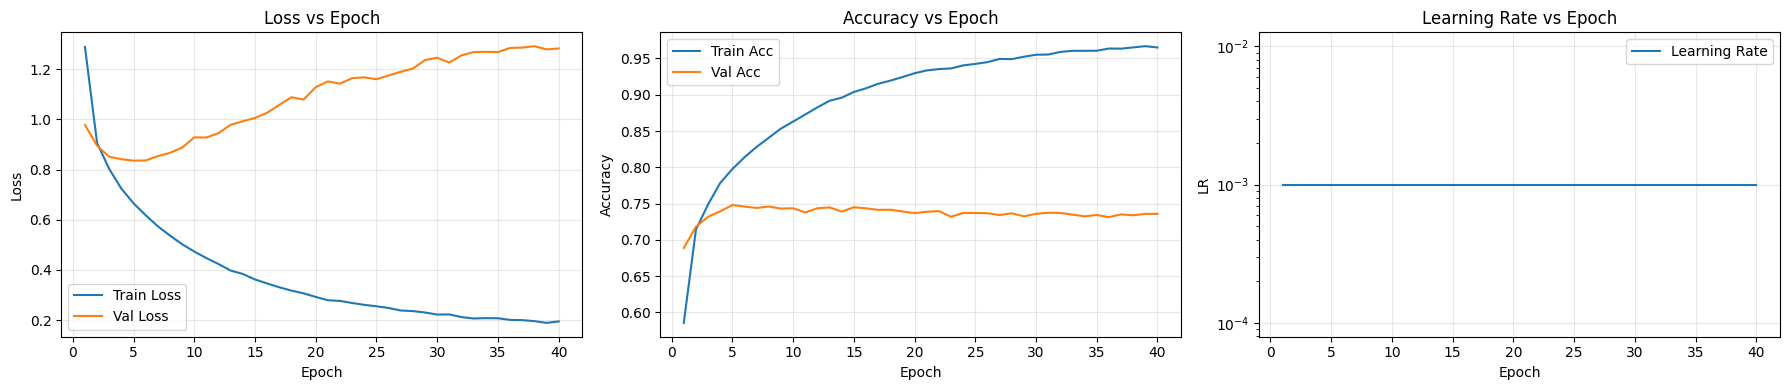

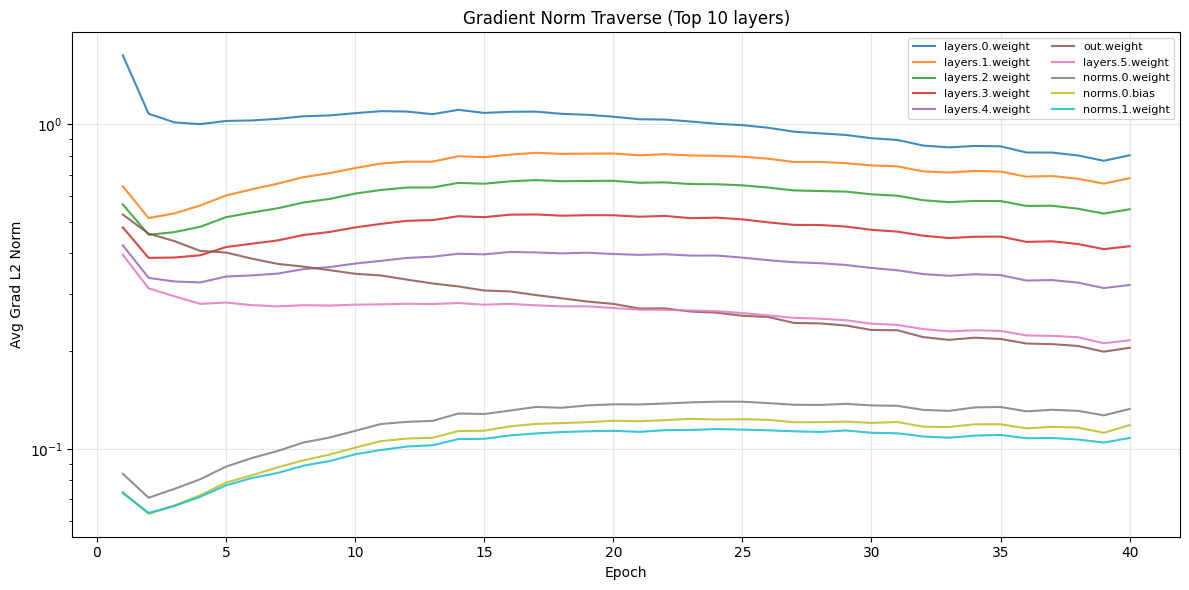

Validation accuracy: 0.748


<Figure size 1200x1000 with 0 Axes>

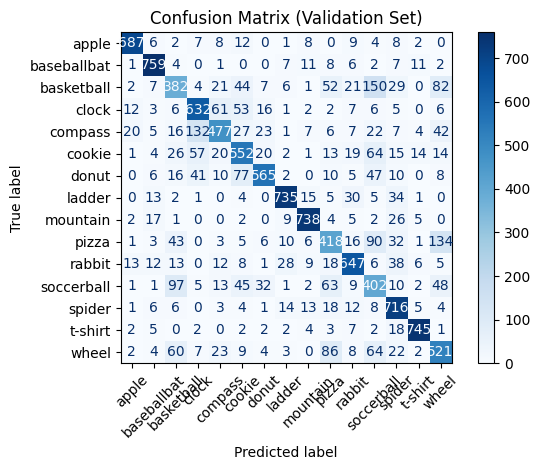

Class-wise accuracy (worst to best):
basketball      : 0.473
pizza           : 0.544
soccerball      : 0.550
compass         : 0.599
wheel           : 0.639
cookie          : 0.672
donut           : 0.709
clock           : 0.778
rabbit          : 0.793
ladder          : 0.870
spider          : 0.883
mountain        : 0.910
apple           : 0.911
baseballbat     : 0.927
t-shirt         : 0.937
Total misclassified samples: 3024
Top misclassified class pairs:
basketball -> soccerball : 150


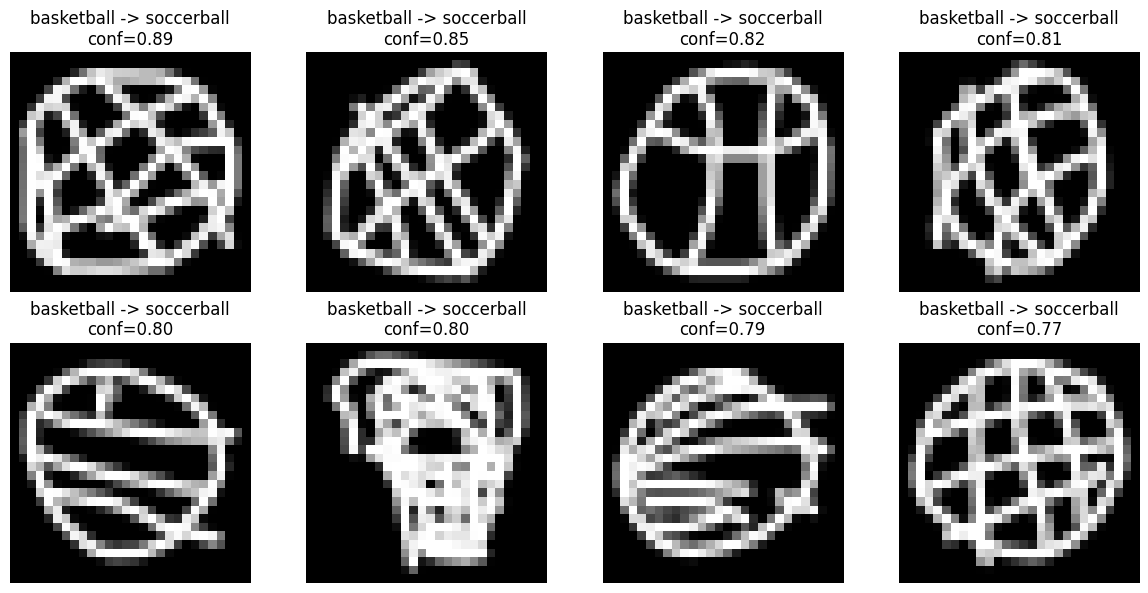

pizza -> wheel : 134


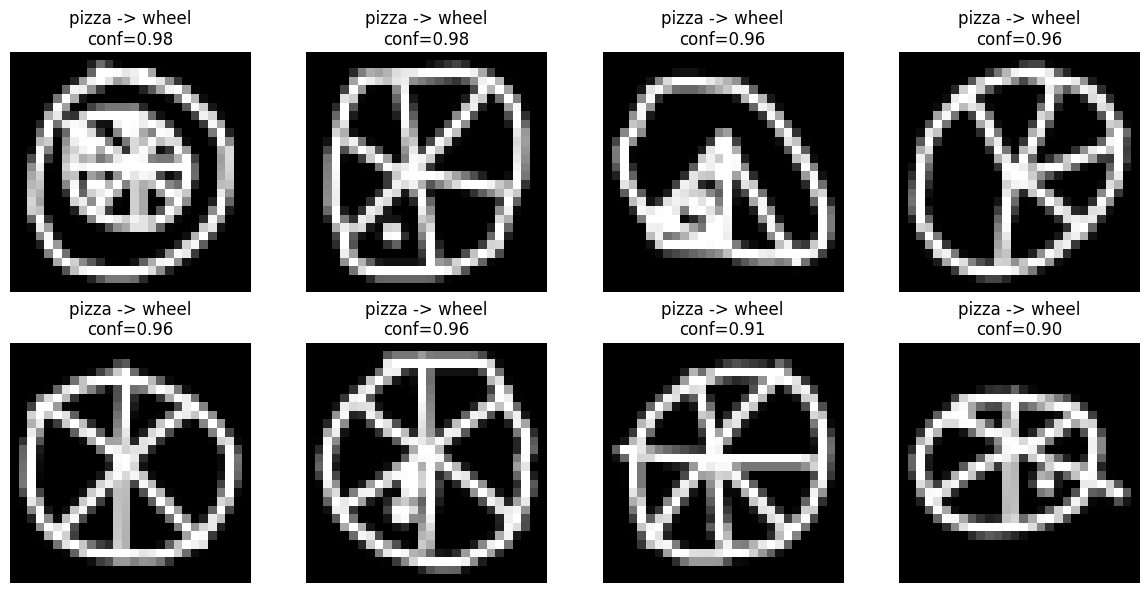

compass -> clock : 132


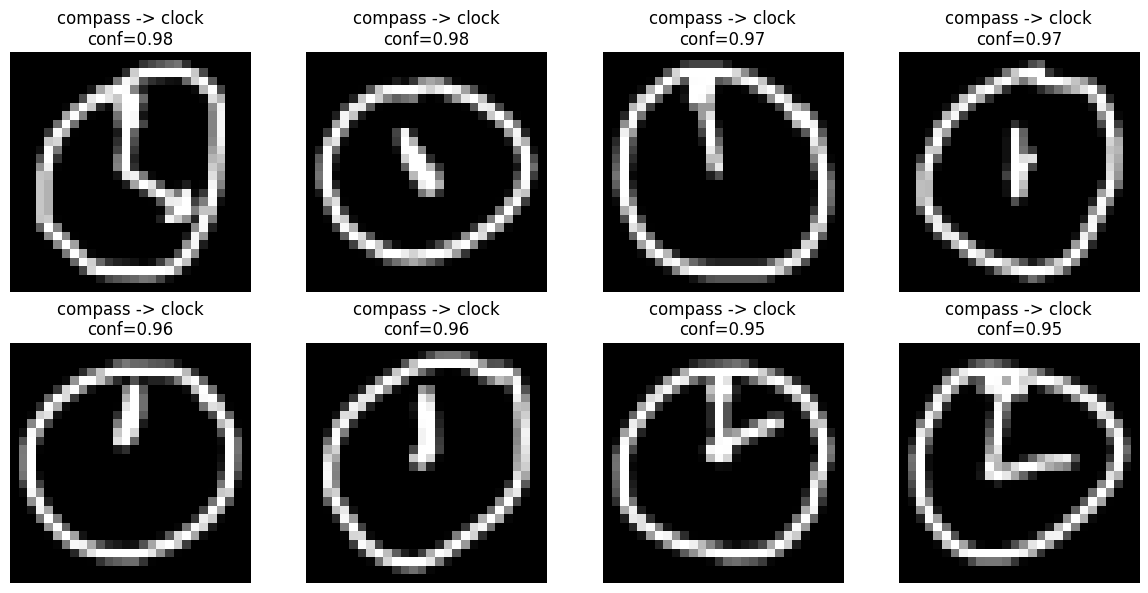

soccerball -> basketball : 97


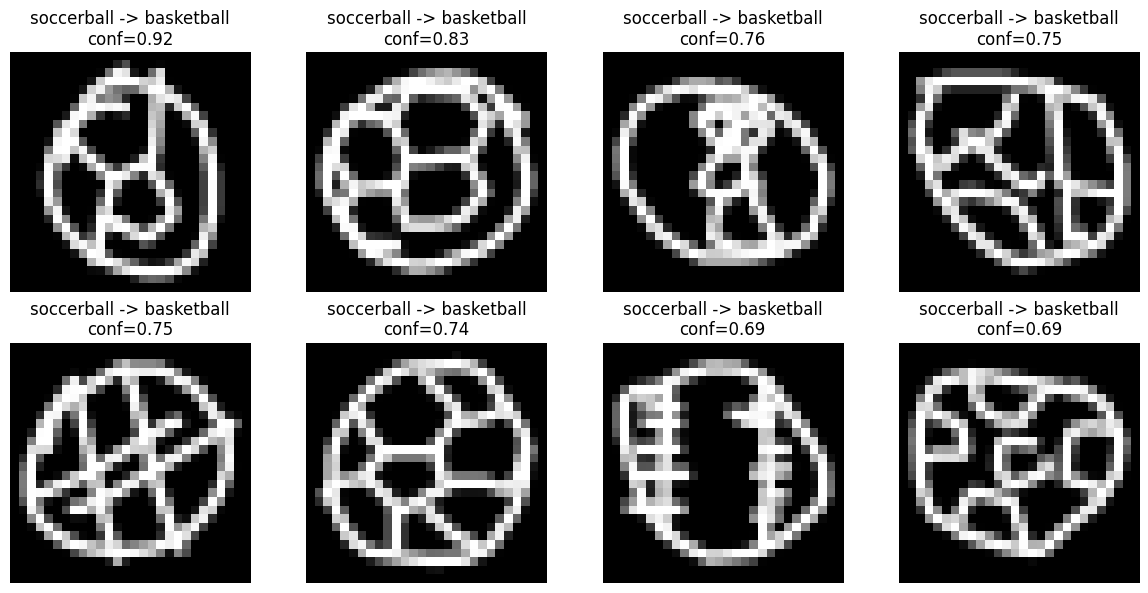

pizza -> soccerball : 90


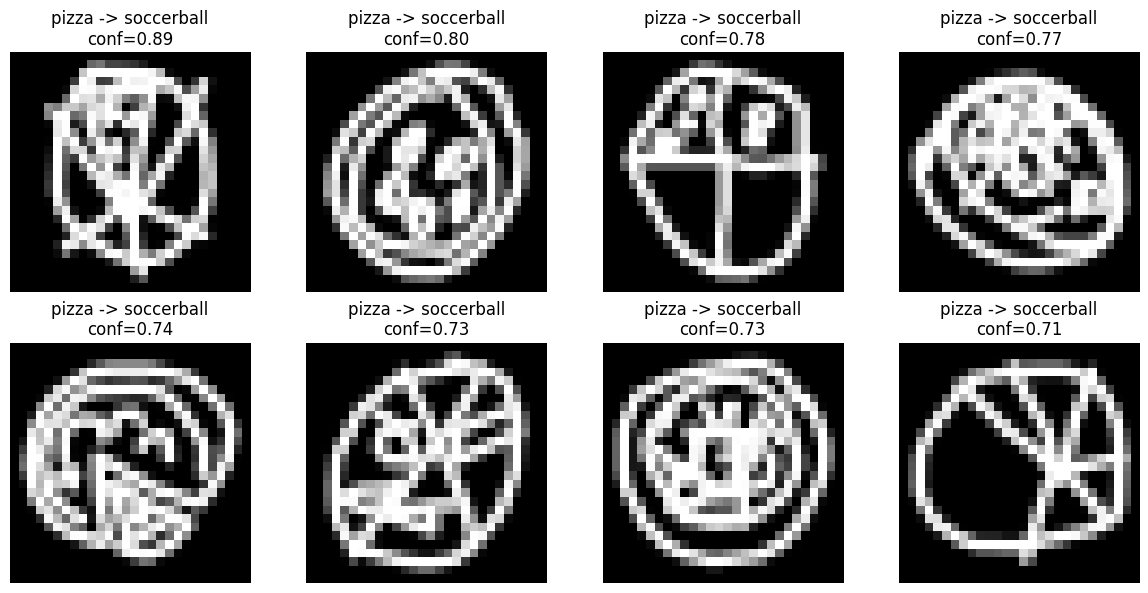

In [12]:
# Tower, width=128, depth =8
tower = TowerMLP(input_size=784, num_classes=NUM_CLASSES, width=128, depth=6, use_batchnorm=True).to(DEVICE)
tower_results = run_model_experiment(
    model=tower,
    model_name="TowerMLP",
    checkpoint_path="best_tower.pth",
)


TowerMLP_w256 trainable params: 536847 | weight_decay=0.0001
Checkpoint path: ./checkpoints/best_tower_w256.pth
[TowerMLP_w256] Epoch 01/40 | Train: loss 1.1627, acc 0.6292 | Val: loss 0.9371, acc 0.7099 | LR: 0.001000 | Best Val: 0.7099 (ep 1)
[TowerMLP_w256] Epoch 02/40 | Train: loss 0.8396, acc 0.7379 | Val: loss 0.8662, acc 0.7312 | LR: 0.001000 | Best Val: 0.7312 (ep 2)
[TowerMLP_w256] Epoch 03/40 | Train: loss 0.7190, acc 0.7805 | Val: loss 0.8118, acc 0.7496 | LR: 0.001000 | Best Val: 0.7496 (ep 3)
[TowerMLP_w256] Epoch 04/40 | Train: loss 0.6272, acc 0.8099 | Val: loss 0.8077, acc 0.7560 | LR: 0.001000 | Best Val: 0.7560 (ep 4)
[TowerMLP_w256] Epoch 05/40 | Train: loss 0.5492, acc 0.8366 | Val: loss 0.8471, acc 0.7538 | LR: 0.001000 | Best Val: 0.7560 (ep 4)
[TowerMLP_w256] Epoch 06/40 | Train: loss 0.4865, acc 0.8595 | Val: loss 0.8634, acc 0.7512 | LR: 0.001000 | Best Val: 0.7560 (ep 4)
[TowerMLP_w256] Epoch 07/40 | Train: loss 0.4281, acc 0.8793 | Val: loss 0.8849, acc 0.75

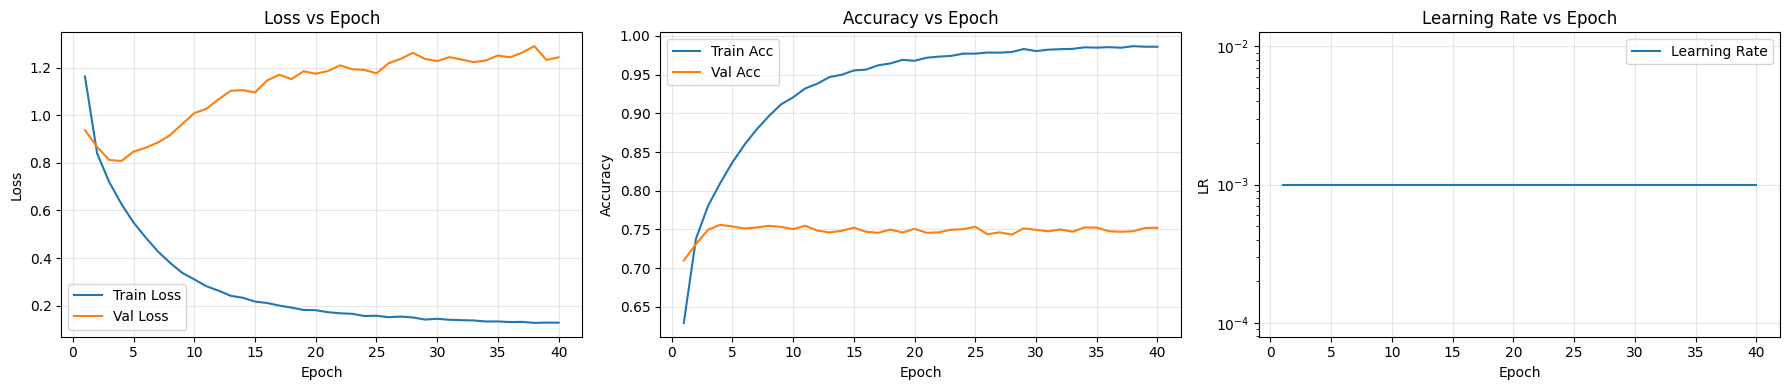

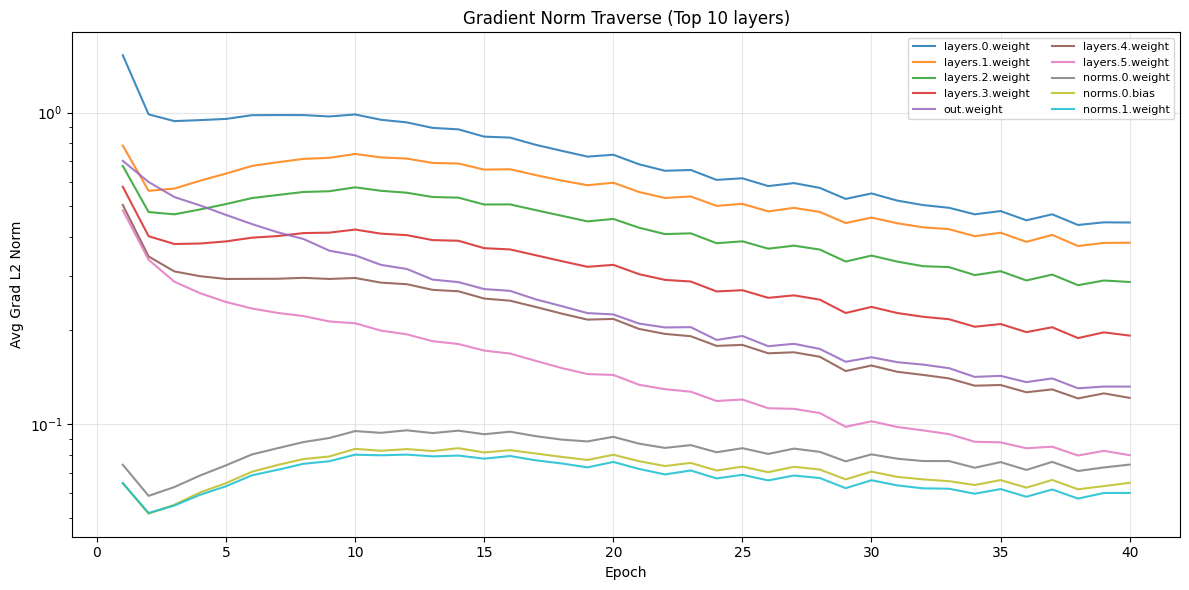

Validation accuracy: 0.756


<Figure size 1200x1000 with 0 Axes>

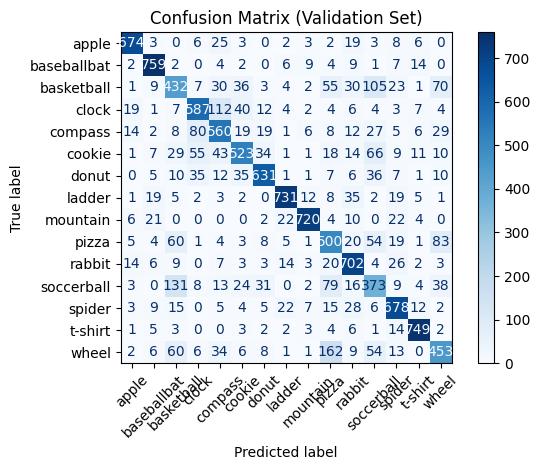

Class-wise accuracy (worst to best):
soccerball      : 0.510
basketball      : 0.535
wheel           : 0.556
cookie          : 0.636
pizza           : 0.651
compass         : 0.704
clock           : 0.723
donut           : 0.792
spider          : 0.836
rabbit          : 0.860
ladder          : 0.865
mountain        : 0.888
apple           : 0.894
baseballbat     : 0.927
t-shirt         : 0.942
Total misclassified samples: 2928
Top misclassified class pairs:
wheel -> pizza : 162


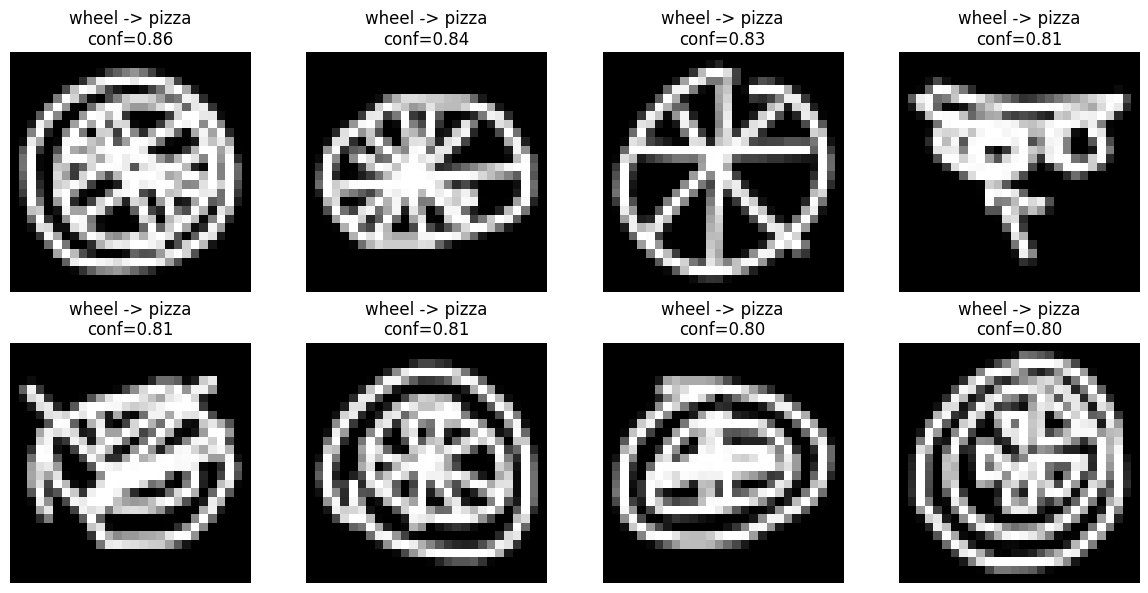

soccerball -> basketball : 131


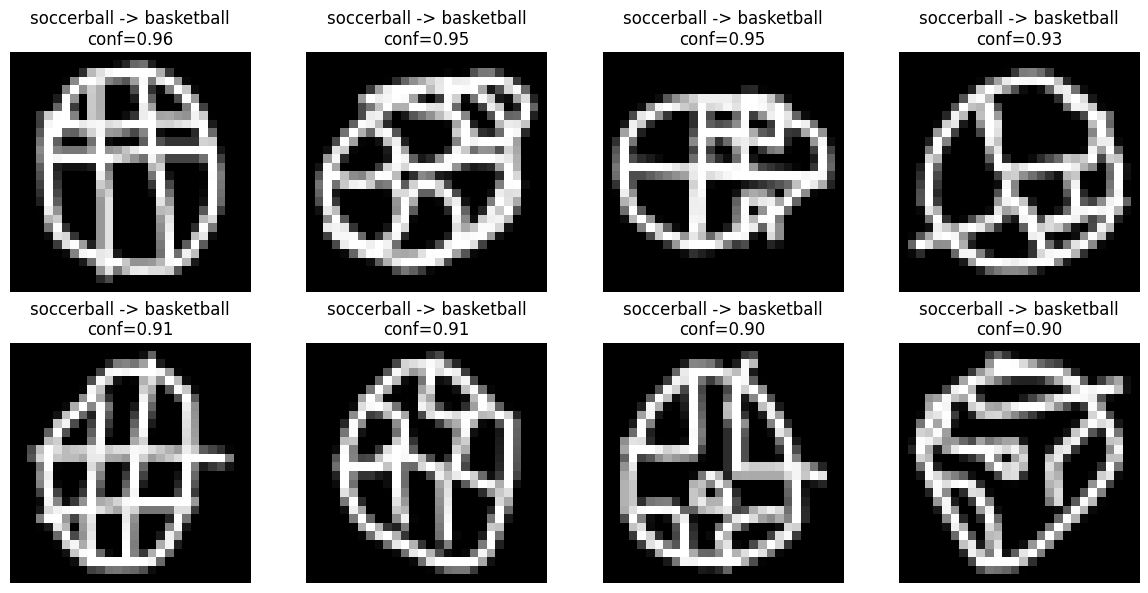

clock -> compass : 112


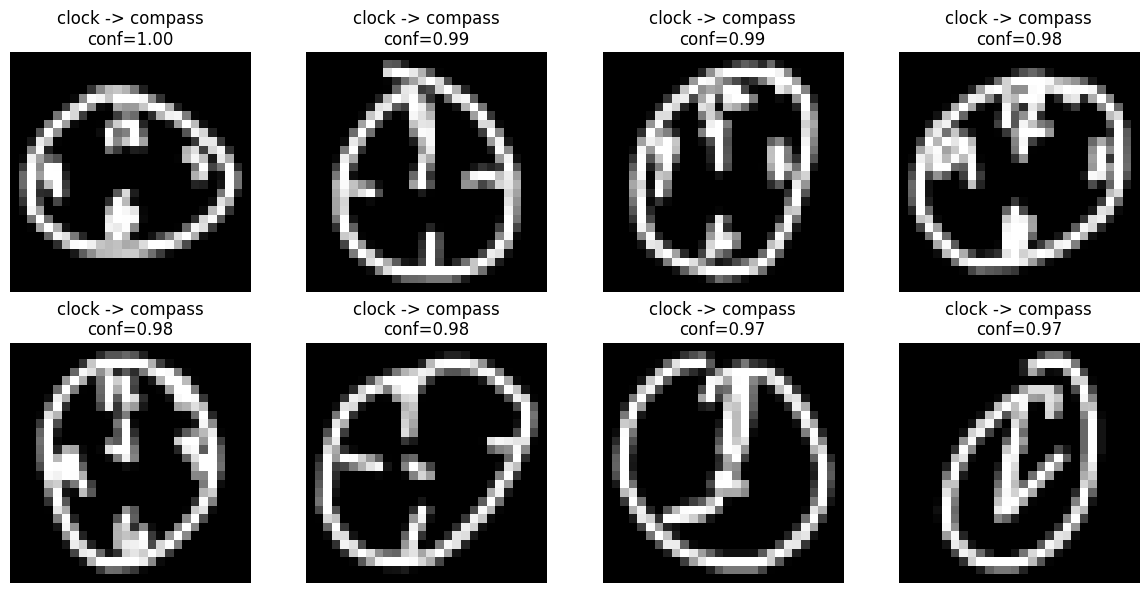

basketball -> soccerball : 105


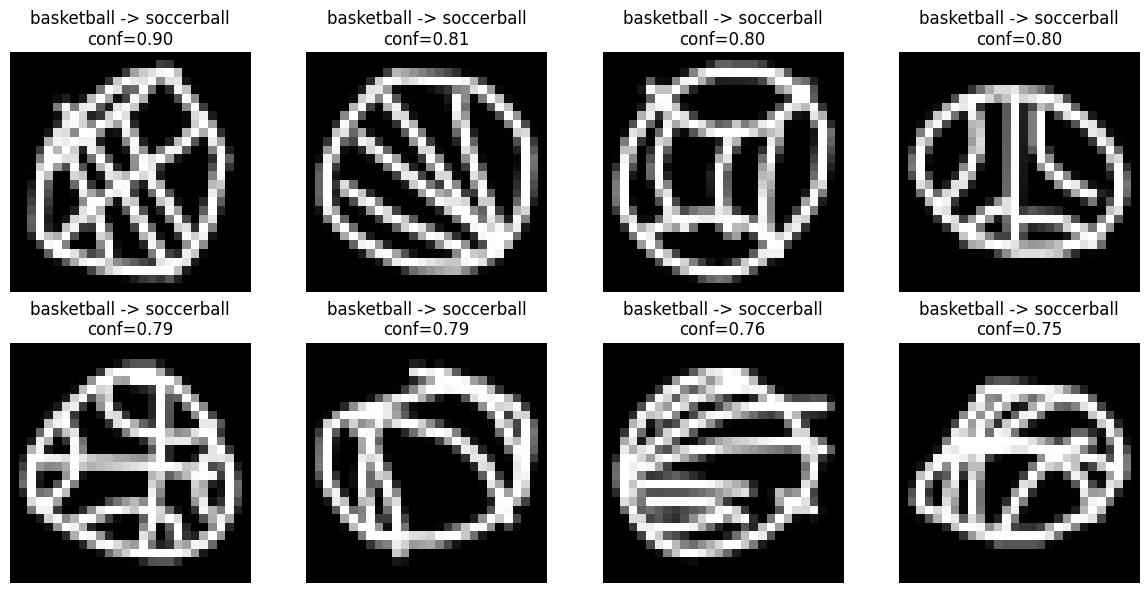

pizza -> wheel : 83


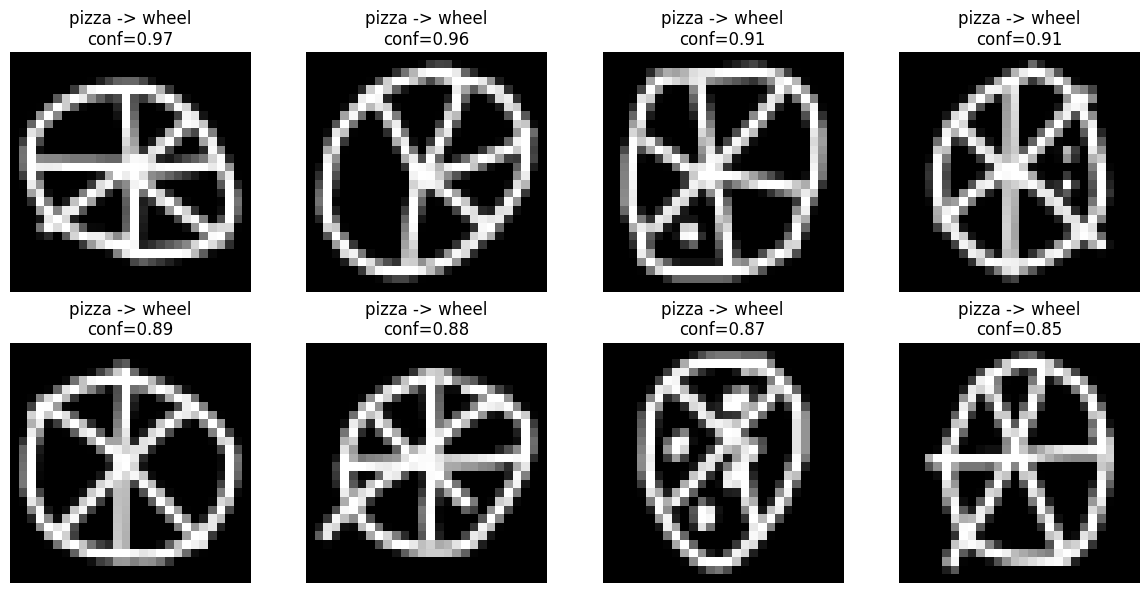

In [13]:
# Tower, width=256, depth =6
tower_256 = TowerMLP(input_size=784, num_classes=NUM_CLASSES, width=256, depth=6, use_batchnorm=True).to(DEVICE)
tower_256_results = run_model_experiment(
    model=tower_256,
    model_name="TowerMLP_w256",
    checkpoint_path="best_tower_w256.pth",
)


TowerMLP_w256_d8 trainable params: 669455 | weight_decay=0.0001
Checkpoint path: ./checkpoints/best_tower_w256_d8.pth
[TowerMLP_w256_d8] Epoch 01/40 | Train: loss 1.2014, acc 0.6117 | Val: loss 0.9583, acc 0.6945 | LR: 0.001000 | Best Val: 0.6945 (ep 1)
[TowerMLP_w256_d8] Epoch 02/40 | Train: loss 0.8724, acc 0.7260 | Val: loss 0.8708, acc 0.7304 | LR: 0.001000 | Best Val: 0.7304 (ep 2)
[TowerMLP_w256_d8] Epoch 03/40 | Train: loss 0.7620, acc 0.7629 | Val: loss 0.8364, acc 0.7405 | LR: 0.001000 | Best Val: 0.7405 (ep 3)
[TowerMLP_w256_d8] Epoch 04/40 | Train: loss 0.6722, acc 0.7974 | Val: loss 0.8338, acc 0.7467 | LR: 0.001000 | Best Val: 0.7467 (ep 4)
[TowerMLP_w256_d8] Epoch 05/40 | Train: loss 0.6049, acc 0.8175 | Val: loss 0.8273, acc 0.7521 | LR: 0.001000 | Best Val: 0.7521 (ep 5)
[TowerMLP_w256_d8] Epoch 06/40 | Train: loss 0.5431, acc 0.8398 | Val: loss 0.8299, acc 0.7546 | LR: 0.001000 | Best Val: 0.7546 (ep 6)
[TowerMLP_w256_d8] Epoch 07/40 | Train: loss 0.4907, acc 0.8574 |

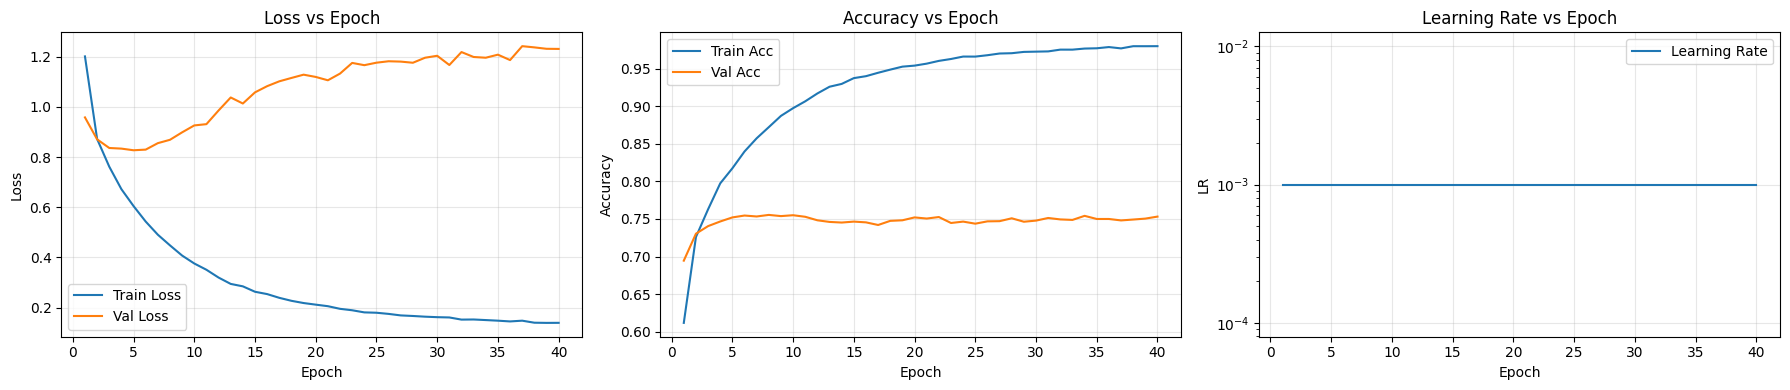

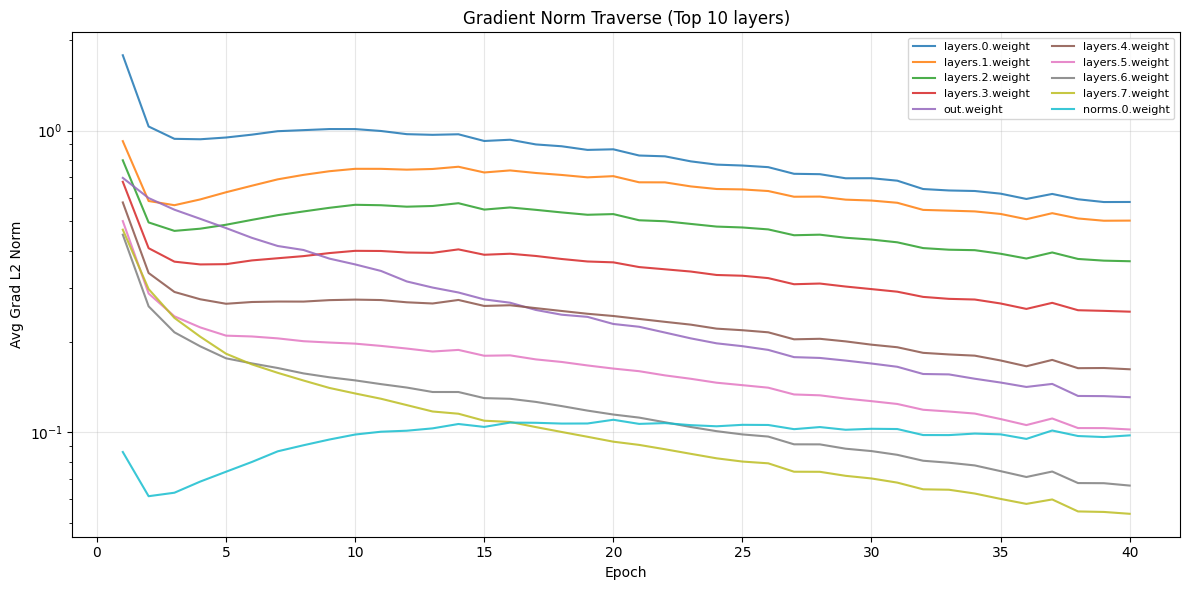

Validation accuracy: 0.7554166666666666


<Figure size 1200x1000 with 0 Axes>

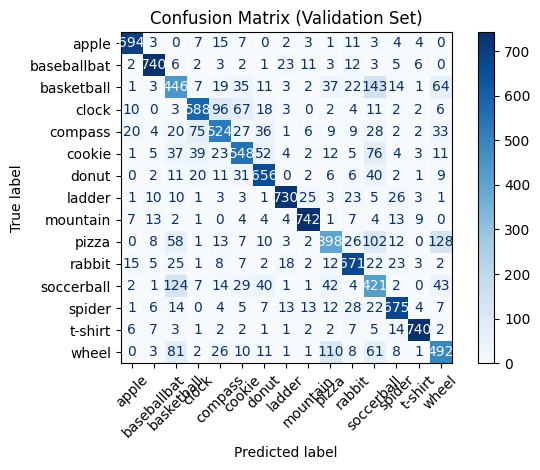

Class-wise accuracy (worst to best):
pizza           : 0.518
basketball      : 0.552
soccerball      : 0.576
wheel           : 0.604
compass         : 0.658
cookie          : 0.667
clock           : 0.724
rabbit          : 0.822
donut           : 0.823
spider          : 0.832
ladder          : 0.864
baseballbat     : 0.904
mountain        : 0.915
apple           : 0.920
t-shirt         : 0.931
Total misclassified samples: 2935
Top misclassified class pairs:
basketball -> soccerball : 143


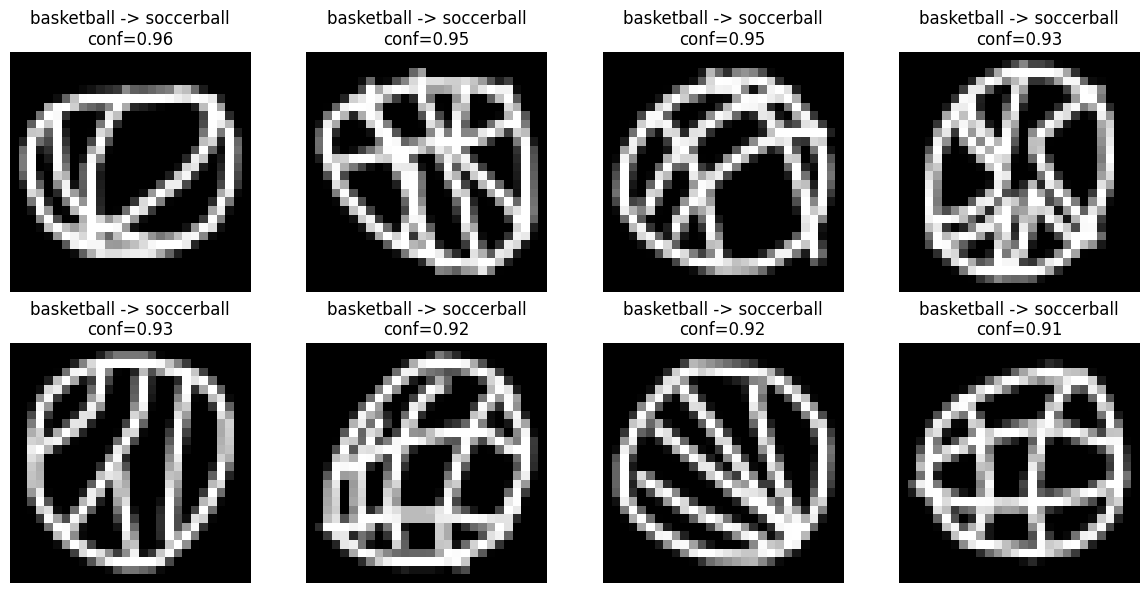

pizza -> wheel : 128


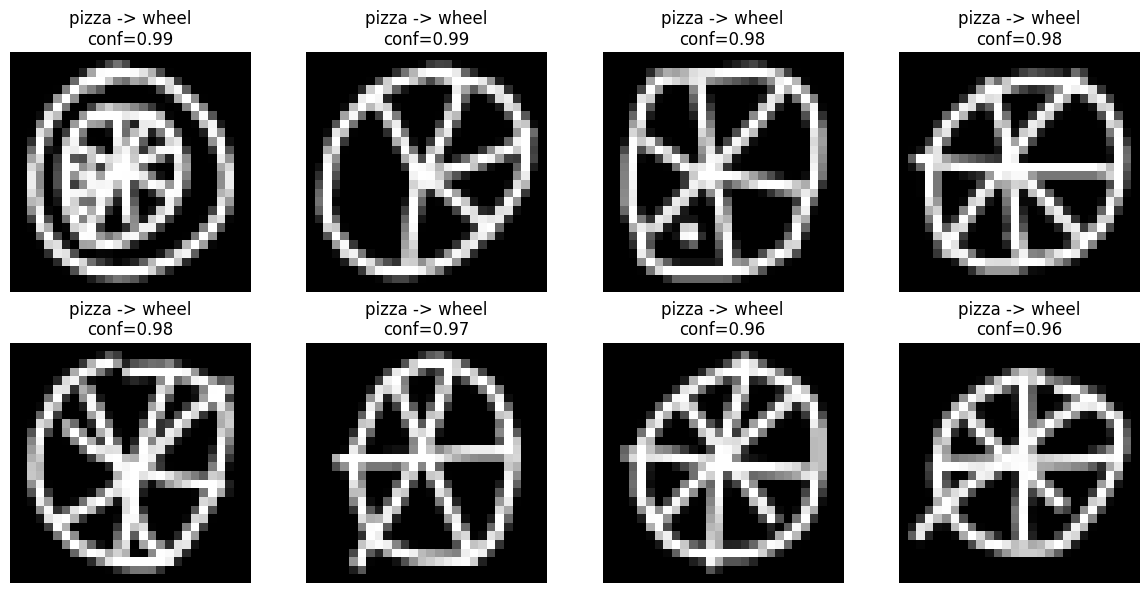

soccerball -> basketball : 124


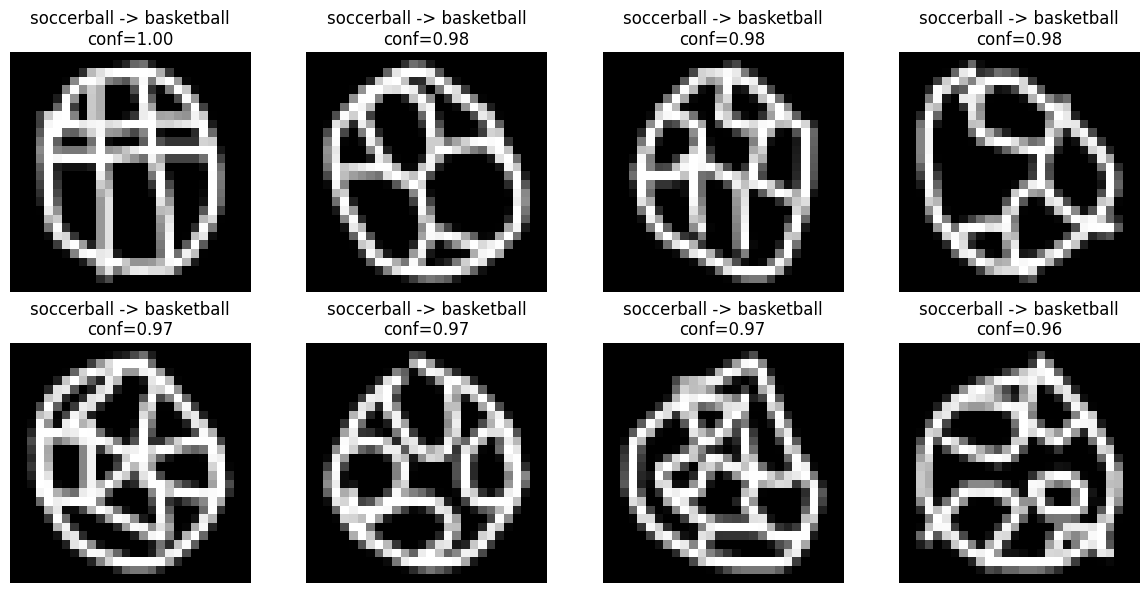

wheel -> pizza : 110


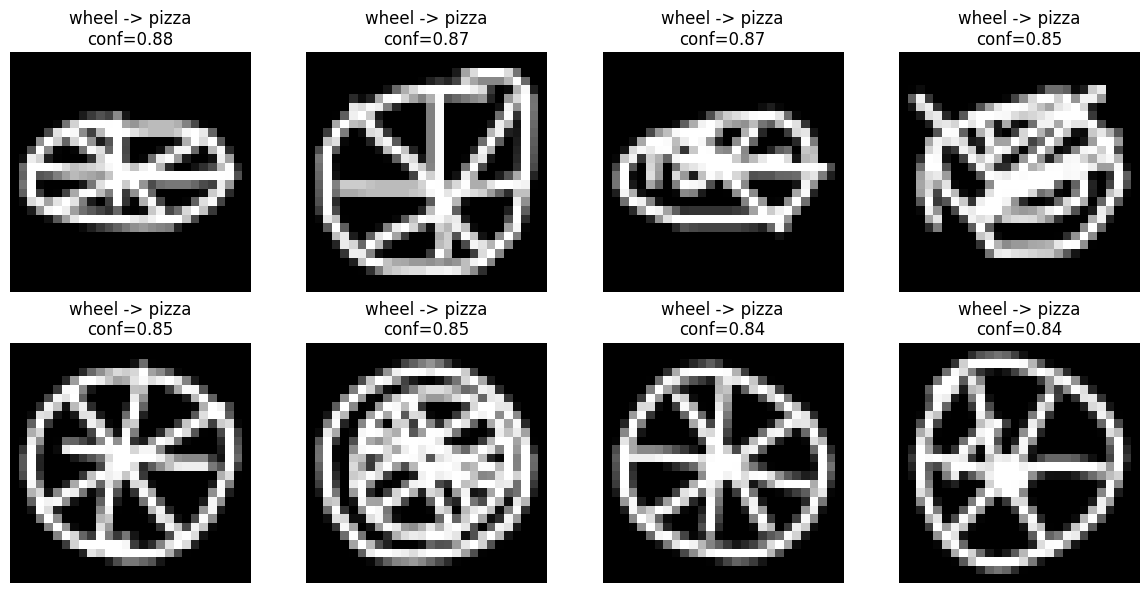

pizza -> soccerball : 102


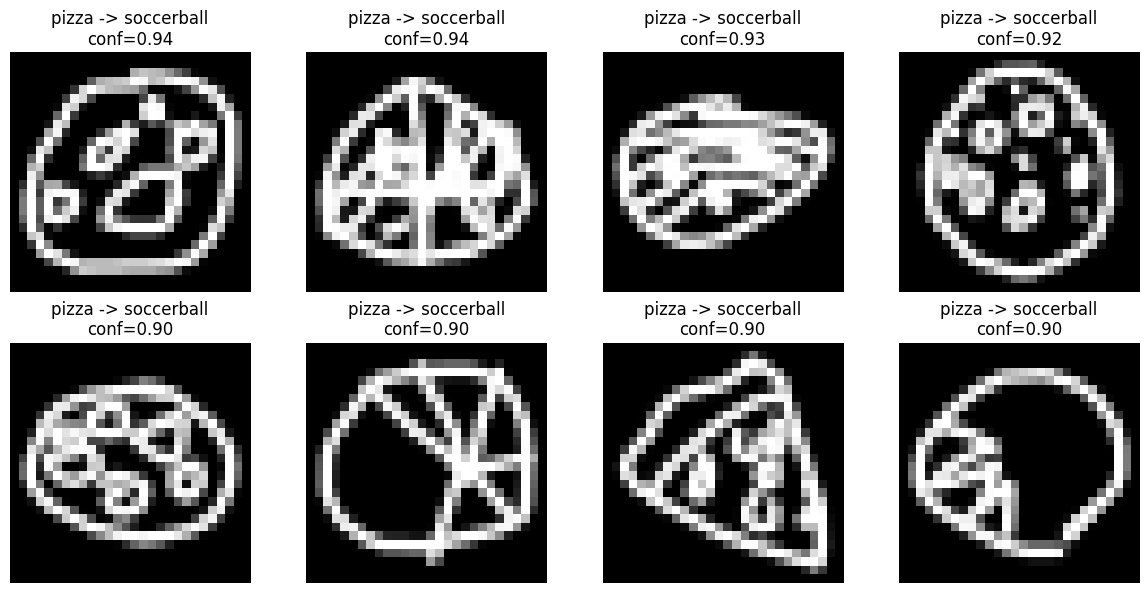

In [14]:
# Tower, width=256, depth =8
tower_256_d8 = TowerMLP(input_size=784, num_classes=NUM_CLASSES, width=256, depth=8, use_batchnorm=True).to(DEVICE)
tower_256_d8_results = run_model_experiment(
    model=tower_256_d8,
    model_name="TowerMLP_w256_d8",
    checkpoint_path="best_tower_w256_d8.pth",
)


PancakeMLP_L2 trainable params: 2933775 | weight_decay=0.001
Checkpoint path: ./checkpoints/best_pancake_l2.pth
[PancakeMLP_L2] Epoch 01/40 | Train: loss 1.0392, acc 0.6740 | Val: loss 0.8753, acc 0.7298 | LR: 0.001000 | Best Val: 0.7298 (ep 1)
[PancakeMLP_L2] Epoch 02/40 | Train: loss 0.7507, acc 0.7703 | Val: loss 0.8057, acc 0.7563 | LR: 0.001000 | Best Val: 0.7563 (ep 2)
[PancakeMLP_L2] Epoch 03/40 | Train: loss 0.5949, acc 0.8222 | Val: loss 0.7882, acc 0.7677 | LR: 0.001000 | Best Val: 0.7677 (ep 3)
[PancakeMLP_L2] Epoch 04/40 | Train: loss 0.4732, acc 0.8637 | Val: loss 0.8061, acc 0.7728 | LR: 0.001000 | Best Val: 0.7728 (ep 4)
[PancakeMLP_L2] Epoch 05/40 | Train: loss 0.3687, acc 0.9035 | Val: loss 0.8972, acc 0.7696 | LR: 0.001000 | Best Val: 0.7728 (ep 4)
[PancakeMLP_L2] Epoch 06/40 | Train: loss 0.2892, acc 0.9323 | Val: loss 0.9551, acc 0.7638 | LR: 0.001000 | Best Val: 0.7728 (ep 4)
[PancakeMLP_L2] Epoch 07/40 | Train: loss 0.2346, acc 0.9530 | Val: loss 1.0323, acc 0.76

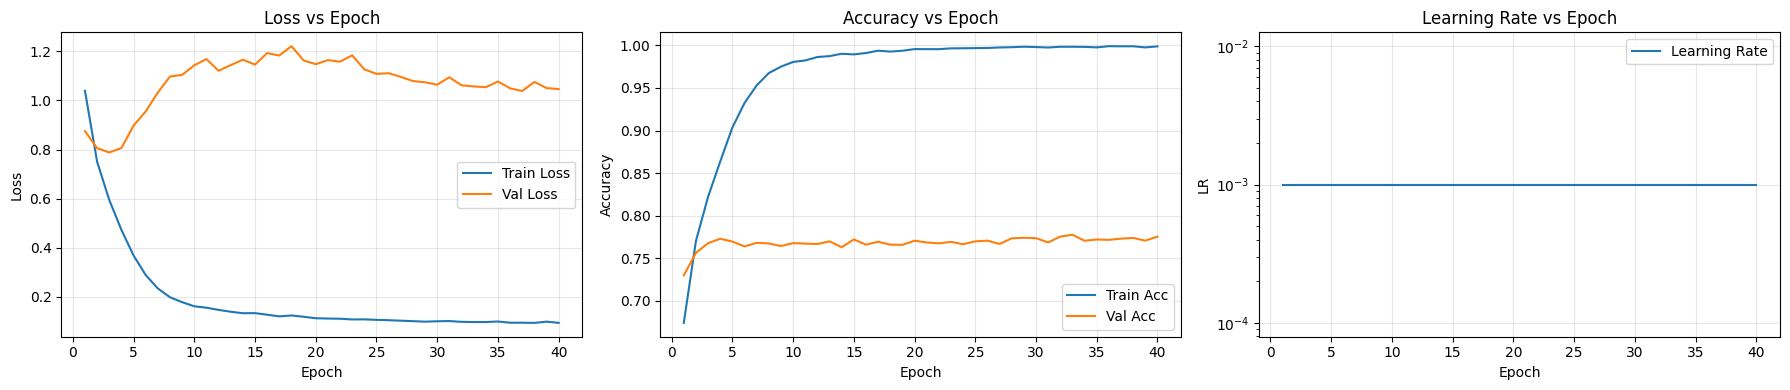

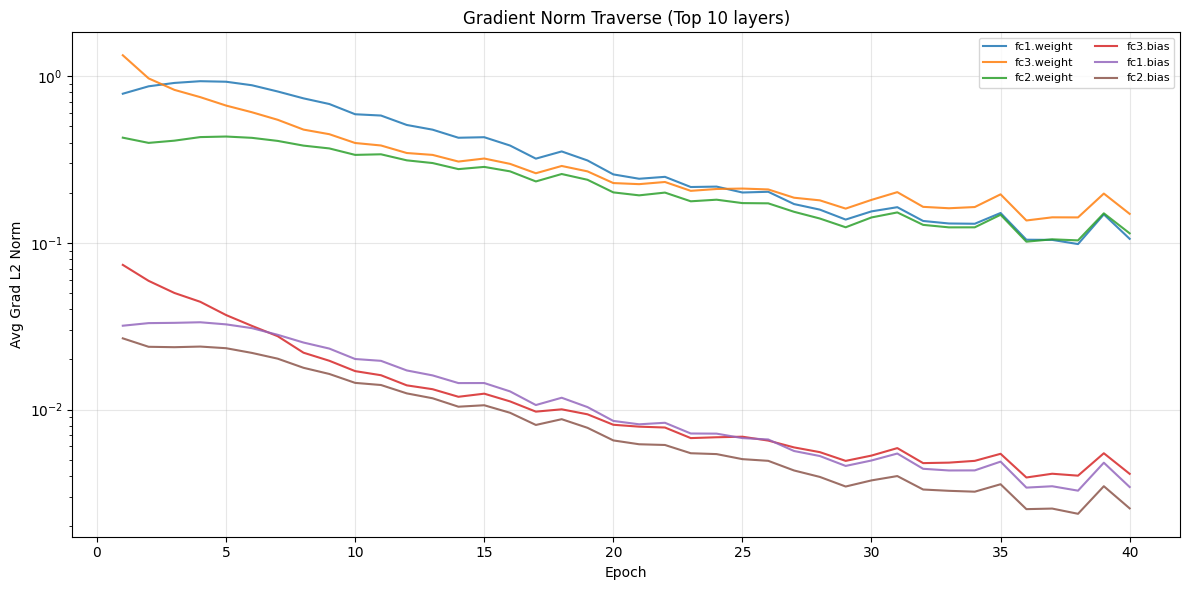

Validation accuracy: 0.7775833333333333


<Figure size 1200x1000 with 0 Axes>

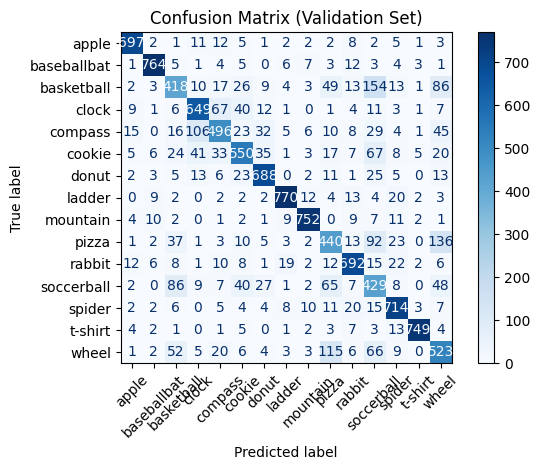

Class-wise accuracy (worst to best):
basketball      : 0.517
pizza           : 0.573
soccerball      : 0.587
compass         : 0.623
wheel           : 0.642
cookie          : 0.669
clock           : 0.799
rabbit          : 0.848
donut           : 0.863
spider          : 0.880
ladder          : 0.911
apple           : 0.924
mountain        : 0.927
baseballbat     : 0.933
t-shirt         : 0.942
Total misclassified samples: 2669
Top misclassified class pairs:
basketball -> soccerball : 154


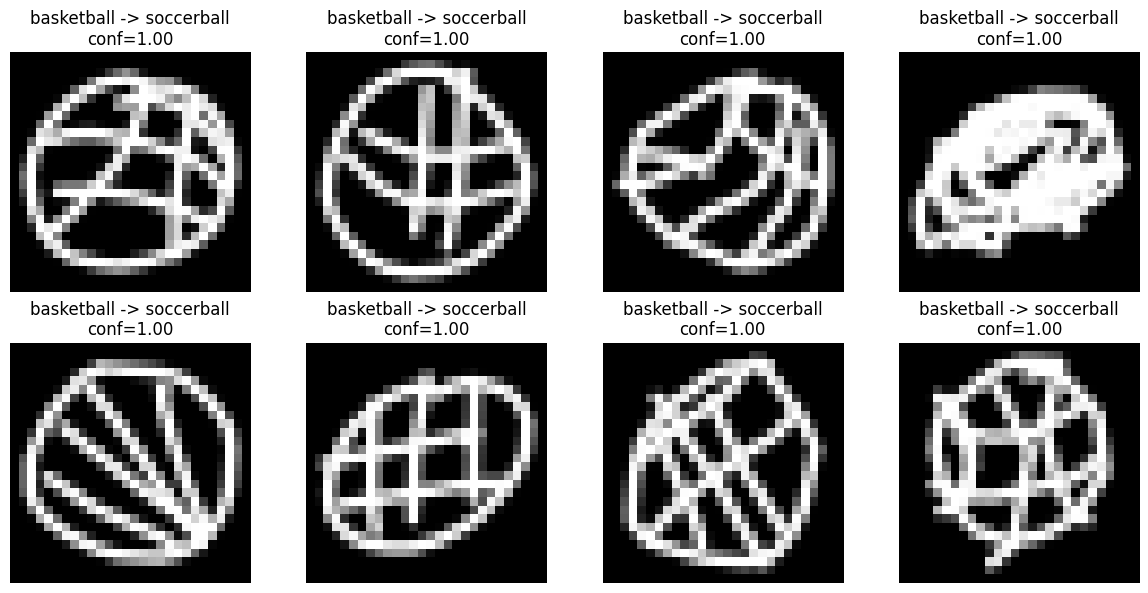

pizza -> wheel : 136


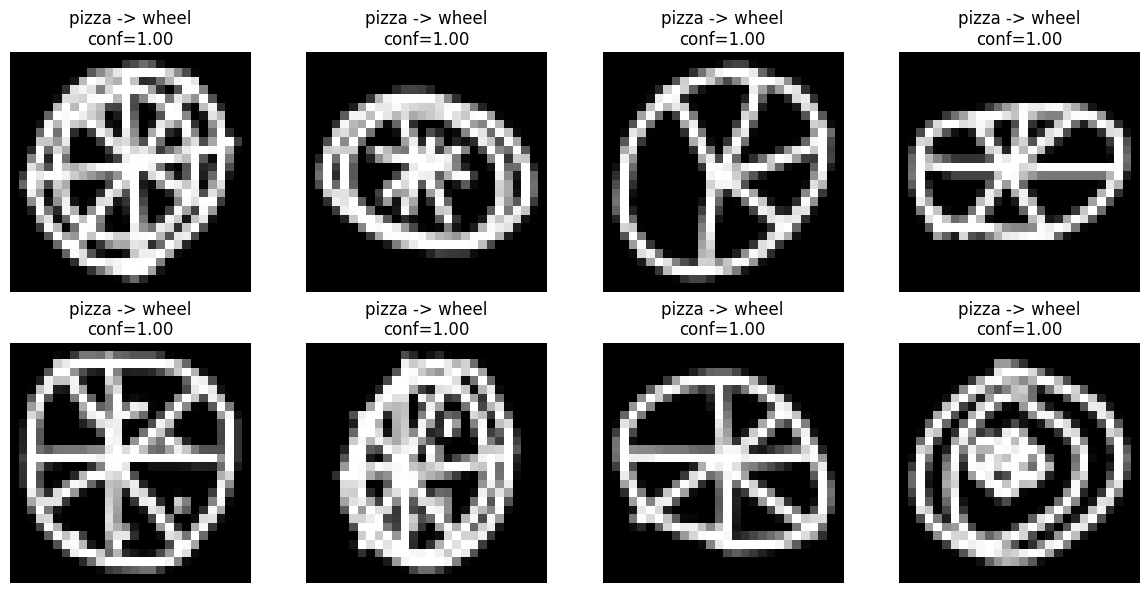

wheel -> pizza : 115


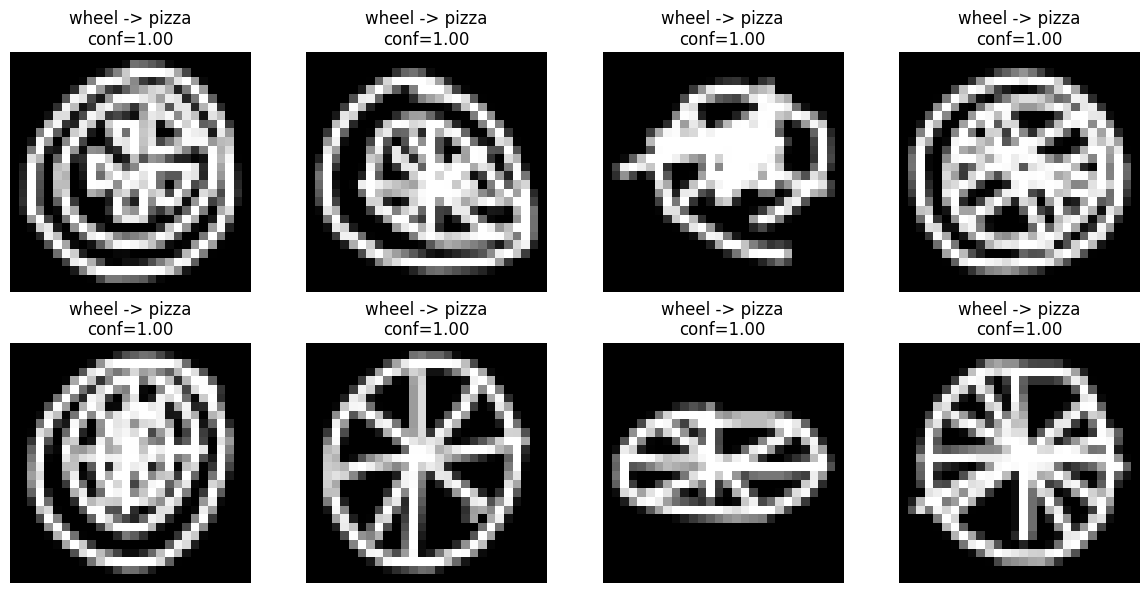

compass -> clock : 106


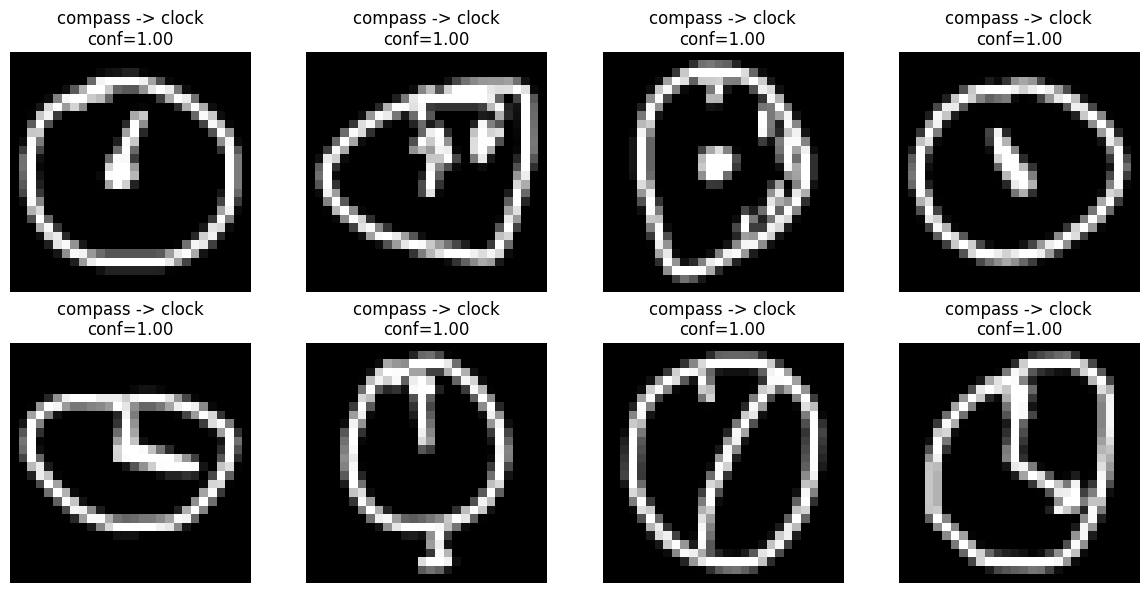

pizza -> soccerball : 92


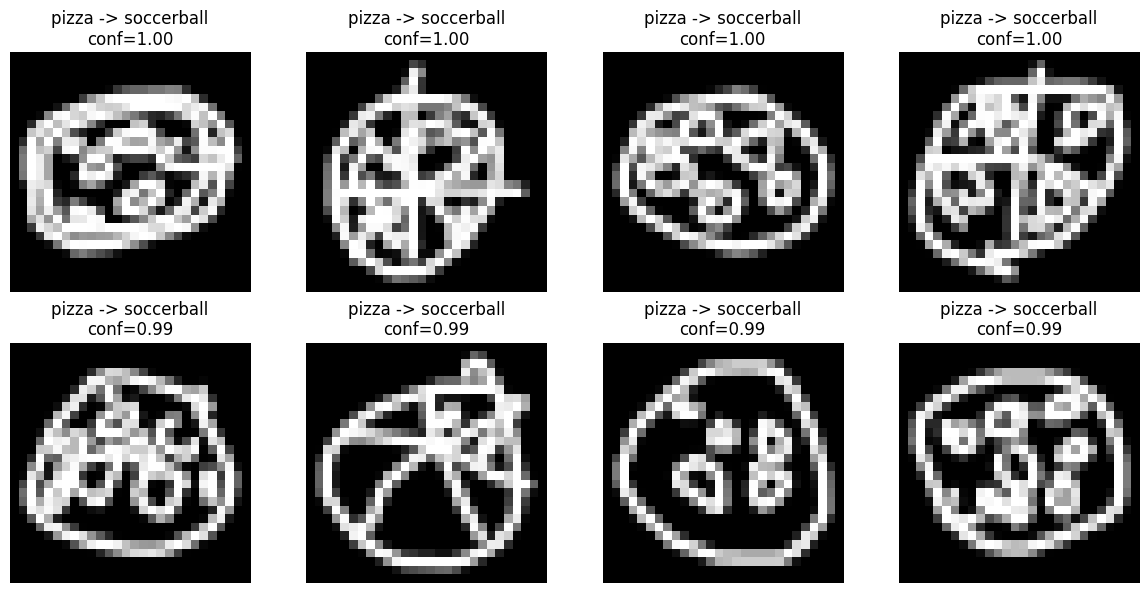


TowerMLP_w256_d8_L2 trainable params: 669455 | weight_decay=0.001
Checkpoint path: ./checkpoints/best_tower_w256_d8_l2.pth
[TowerMLP_w256_d8_L2] Epoch 01/40 | Train: loss 1.2148, acc 0.6067 | Val: loss 0.9472, acc 0.7026 | LR: 0.001000 | Best Val: 0.7026 (ep 1)
[TowerMLP_w256_d8_L2] Epoch 02/40 | Train: loss 0.8787, acc 0.7240 | Val: loss 0.8801, acc 0.7227 | LR: 0.001000 | Best Val: 0.7227 (ep 2)
[TowerMLP_w256_d8_L2] Epoch 03/40 | Train: loss 0.7669, acc 0.7621 | Val: loss 0.8432, acc 0.7440 | LR: 0.001000 | Best Val: 0.7440 (ep 3)
[TowerMLP_w256_d8_L2] Epoch 04/40 | Train: loss 0.6786, acc 0.7931 | Val: loss 0.8361, acc 0.7470 | LR: 0.001000 | Best Val: 0.7470 (ep 4)
[TowerMLP_w256_d8_L2] Epoch 05/40 | Train: loss 0.6127, acc 0.8156 | Val: loss 0.8568, acc 0.7489 | LR: 0.001000 | Best Val: 0.7489 (ep 5)
[TowerMLP_w256_d8_L2] Epoch 06/40 | Train: loss 0.5485, acc 0.8377 | Val: loss 0.8547, acc 0.7492 | LR: 0.001000 | Best Val: 0.7492 (ep 6)
[TowerMLP_w256_d8_L2] Epoch 07/40 | Train:

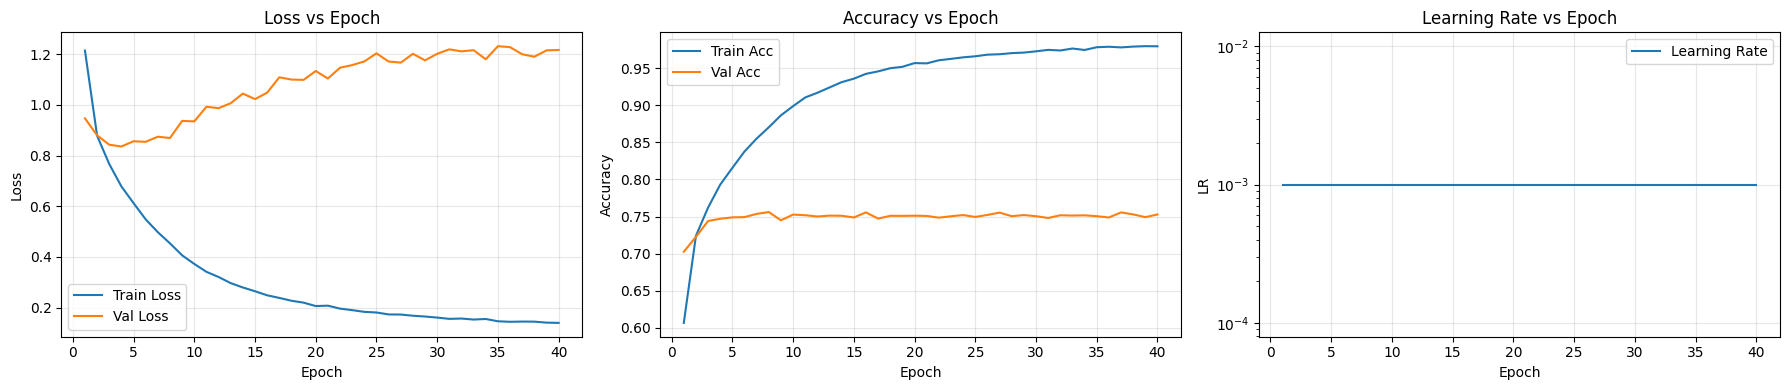

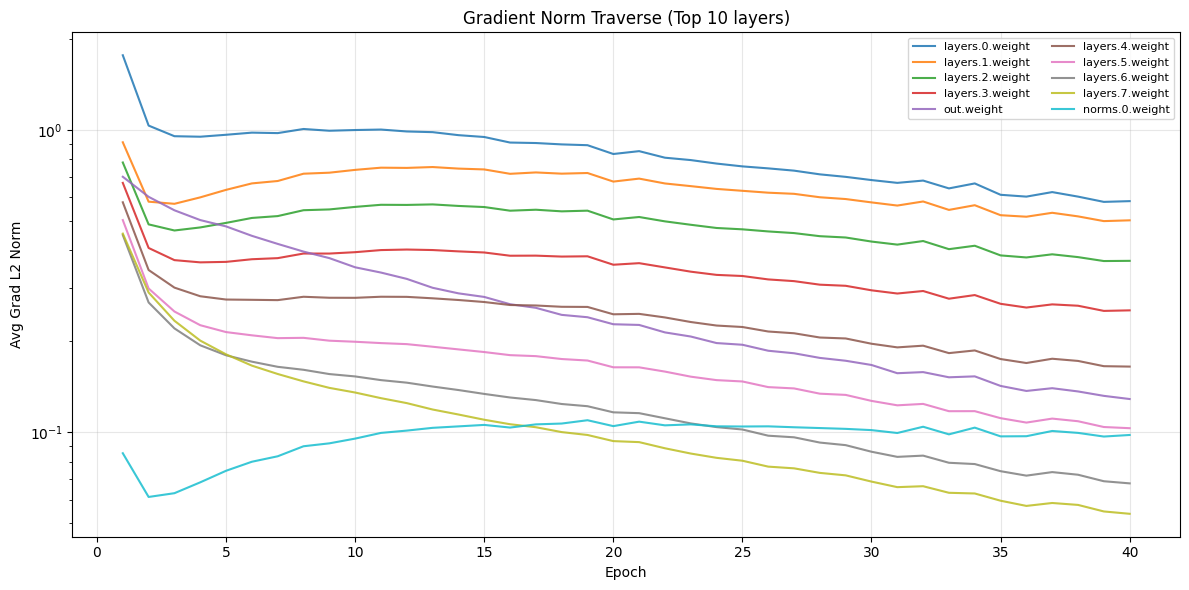

Validation accuracy: 0.7560833333333333


<Figure size 1200x1000 with 0 Axes>

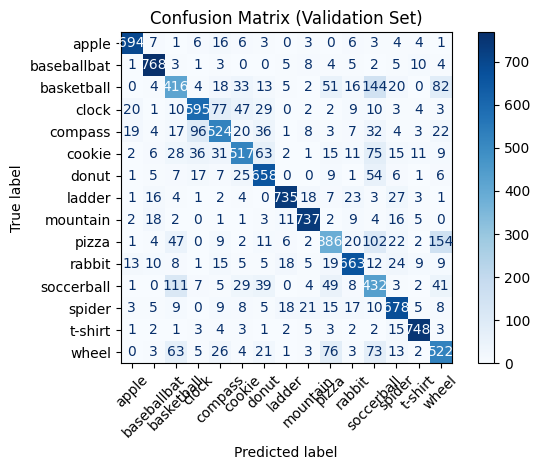

Class-wise accuracy (worst to best):
pizza           : 0.503
basketball      : 0.515
soccerball      : 0.591
cookie          : 0.629
wheel           : 0.640
compass         : 0.658
clock           : 0.733
rabbit          : 0.812
donut           : 0.826
spider          : 0.836
ladder          : 0.870
mountain        : 0.909
apple           : 0.920
baseballbat     : 0.938
t-shirt         : 0.941
Total misclassified samples: 2927
Top misclassified class pairs:
pizza -> wheel : 154


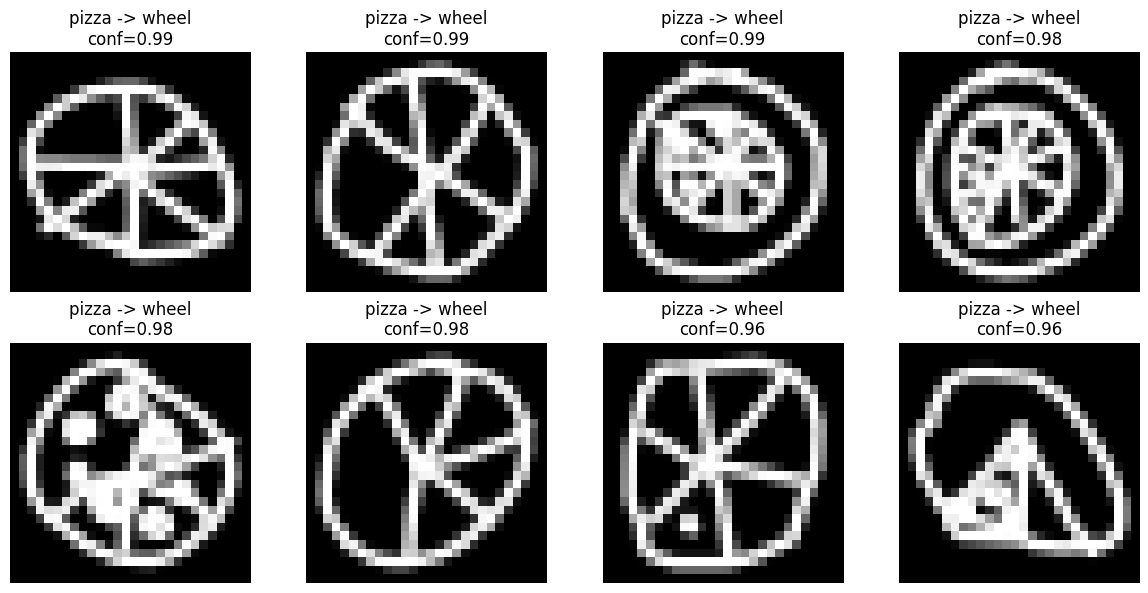

basketball -> soccerball : 144


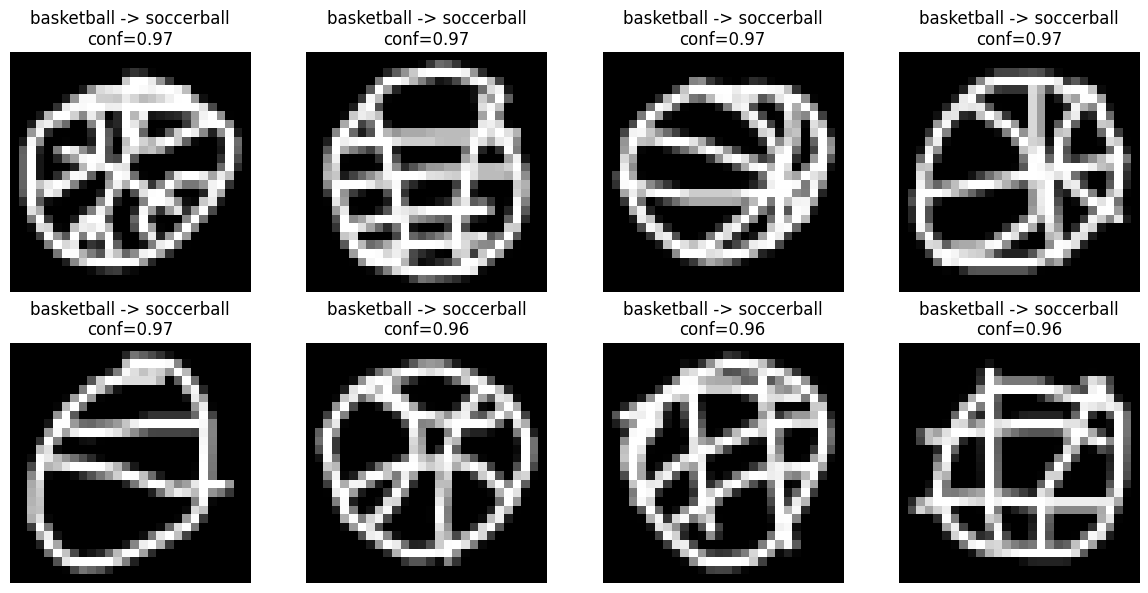

soccerball -> basketball : 111


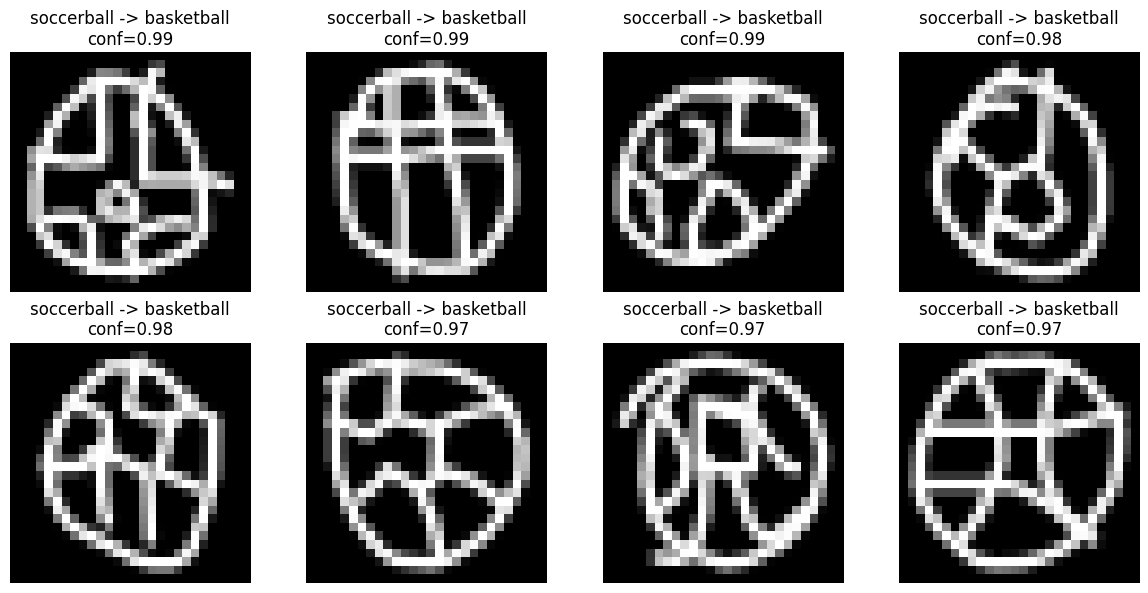

pizza -> soccerball : 102


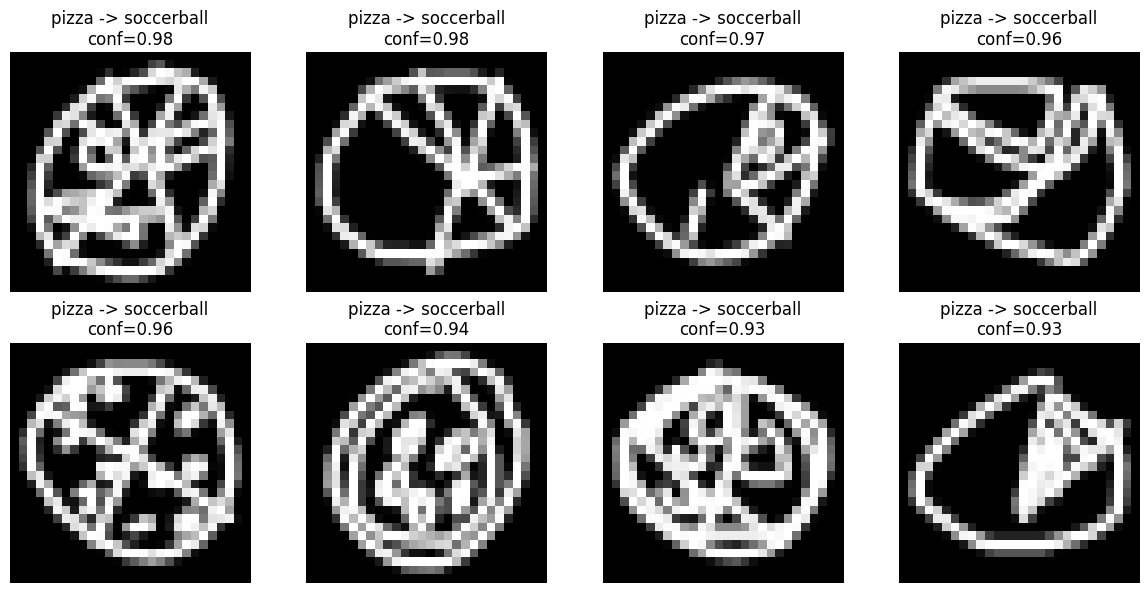

compass -> clock : 96


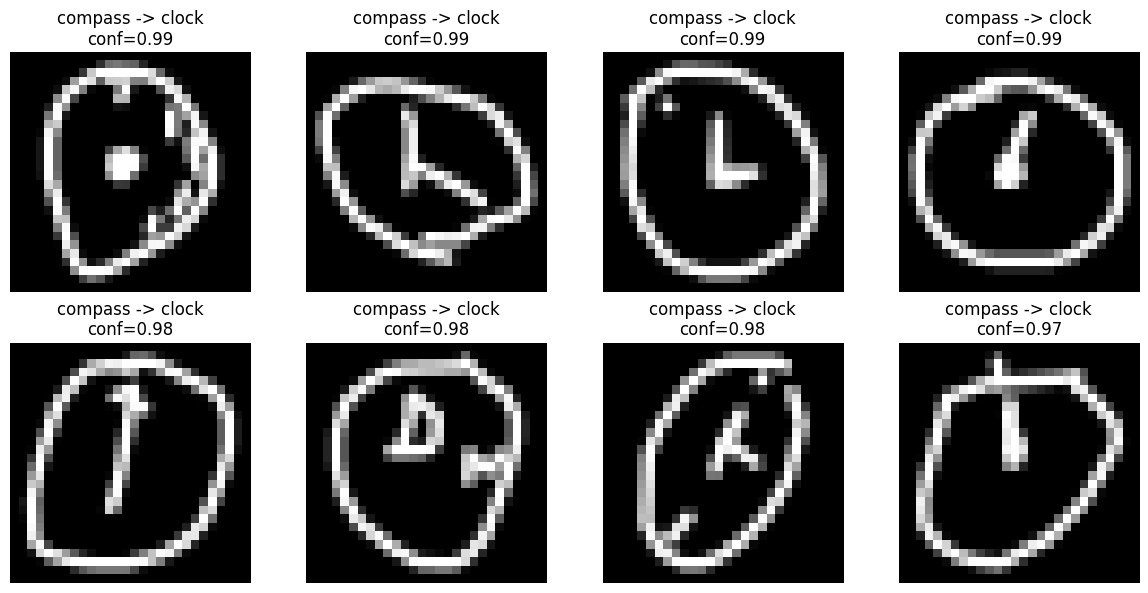

In [15]:
# L2-regularized variants
L2_WEIGHT_DECAY = 1e-3

pancake_l2 = PancakeMLP(input_size=784, num_classes=NUM_CLASSES, h1=1024, h2=2048, num_hidden=2).to(DEVICE)
pancake_l2_results = run_model_experiment(
    model=pancake_l2,
    model_name="PancakeMLP_L2",
    checkpoint_path="best_pancake_l2.pth",
    weight_decay=L2_WEIGHT_DECAY,
)

tower_256_d8_l2 = TowerMLP(input_size=784, num_classes=NUM_CLASSES, width=256, depth=8, use_batchnorm=True).to(DEVICE)
tower_256_d8_l2_results = run_model_experiment(
    model=tower_256_d8_l2,
    model_name="TowerMLP_w256_d8_L2",
    checkpoint_path="best_tower_w256_d8_l2.pth",
    weight_decay=L2_WEIGHT_DECAY,
)

Model comparison summary (Training vs Validation):
PancakeMLP_L2      | Params: 2,933,775 | Best Train/Val: 0.9991/0.7776 (best ep 33) | Final Train/Val: 0.9988/0.7753 | Generalization Gap: +0.2235 | Val Acc/MParam: 0.2650 | Final Val Loss: 1.0462
PancakeMLP         | Params: 2,933,775 | Best Train/Val: 0.9988/0.7738 (best ep 39) | Final Train/Val: 0.9988/0.7722 | Generalization Gap: +0.2265 | Val Acc/MParam: 0.2638 | Final Val Loss: 1.0365
TowerMLP_w256_d8_L2 | Params:   669,455 | Best Train/Val: 0.9796/0.7561 (best ep 8) | Final Train/Val: 0.9794/0.7528 | Generalization Gap: +0.2266 | Val Acc/MParam: 1.1294 | Final Val Loss: 1.2173
TowerMLP_w256      | Params:   536,847 | Best Train/Val: 0.9868/0.7560 (best ep 4) | Final Train/Val: 0.9861/0.7522 | Generalization Gap: +0.2339 | Val Acc/MParam: 1.4082 | Final Val Loss: 1.2433
TowerMLP_w256_d8   | Params:   669,455 | Best Train/Val: 0.9800/0.7554 (best ep 8) | Final Train/Val: 0.9800/0.7532 | Generalization Gap: +0.2268 | Val Acc/MParam

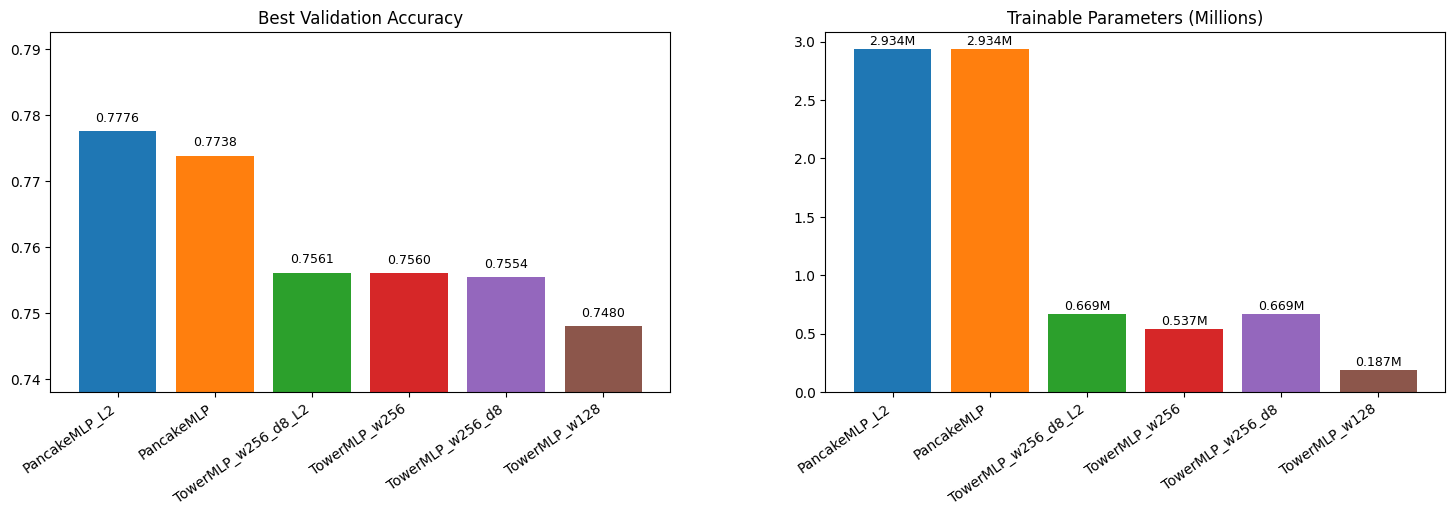


Total labeled samples used for class distribution: 60000
Saved plot: ./comparison/baseline_class_distribution.png


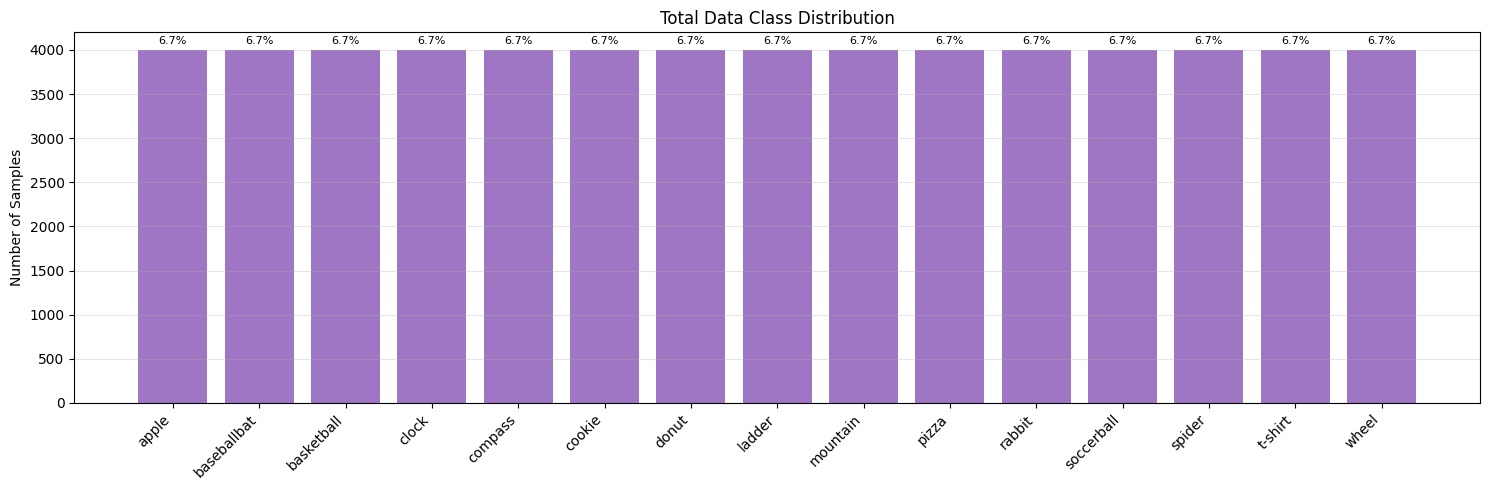

Saved plot: ./comparison/baseline_classwise_accuracy.png


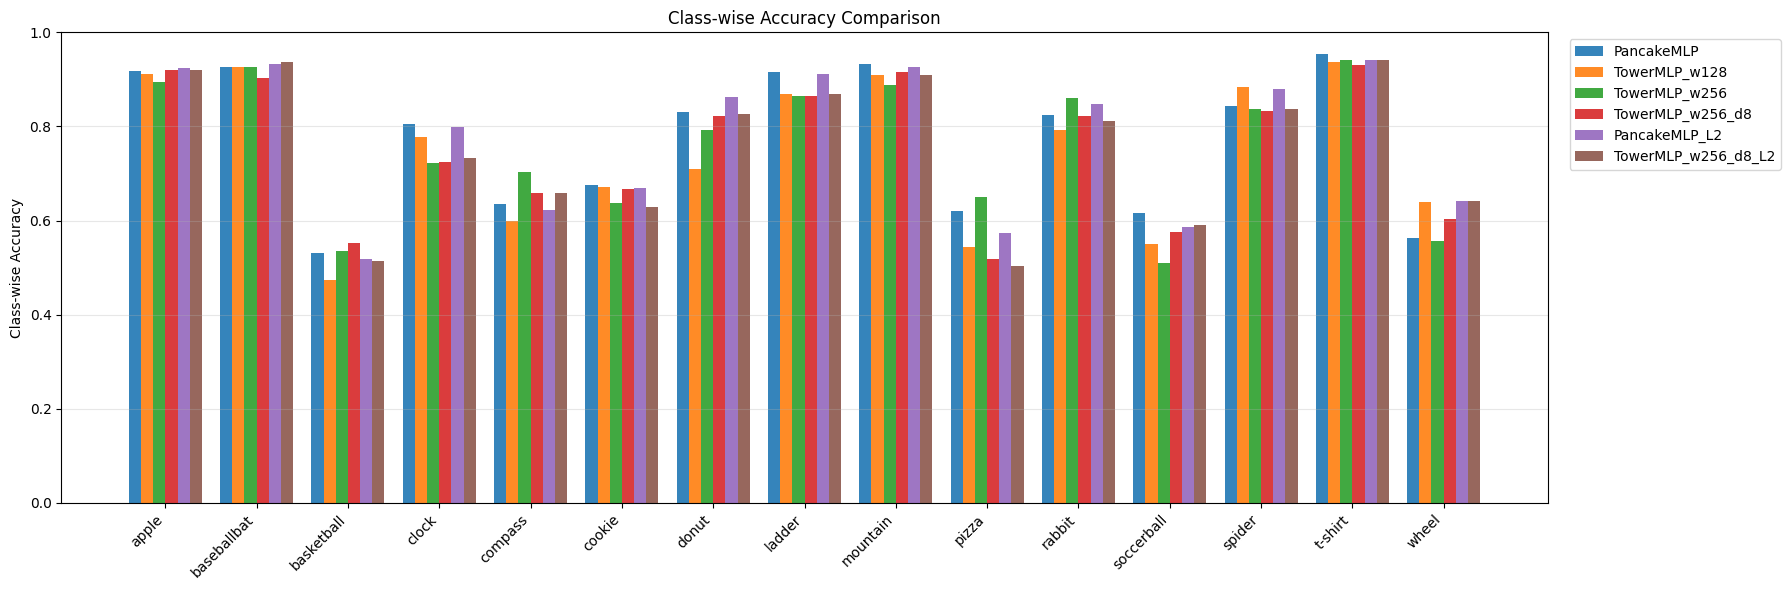


Class-wise accuracy delta vs PancakeMLP:

TowerMLP_w128 - PancakeMLP
donut           : -0.122
pizza           : -0.077
soccerball      : -0.066
basketball      : -0.058
ladder          : -0.045
compass         : -0.036
rabbit          : -0.031
clock           : -0.026
mountain        : -0.022
t-shirt         : -0.016
apple           : -0.007
cookie          : -0.005
baseballbat     : +0.000
spider          : +0.039
wheel           : +0.076

TowerMLP_w256 - PancakeMLP
soccerball      : -0.105
clock           : -0.081
ladder          : -0.050
mountain        : -0.044
cookie          : -0.040
donut           : -0.039
apple           : -0.024
t-shirt         : -0.011
spider          : -0.007
wheel           : -0.007
baseballbat     : +0.000
basketball      : +0.004
pizza           : +0.030
rabbit          : +0.037
compass         : +0.068

TowerMLP_w256_d8 - PancakeMLP
pizza           : -0.103
clock           : -0.080
ladder          : -0.051
soccerball      : -0.040
baseballbat     : -0.

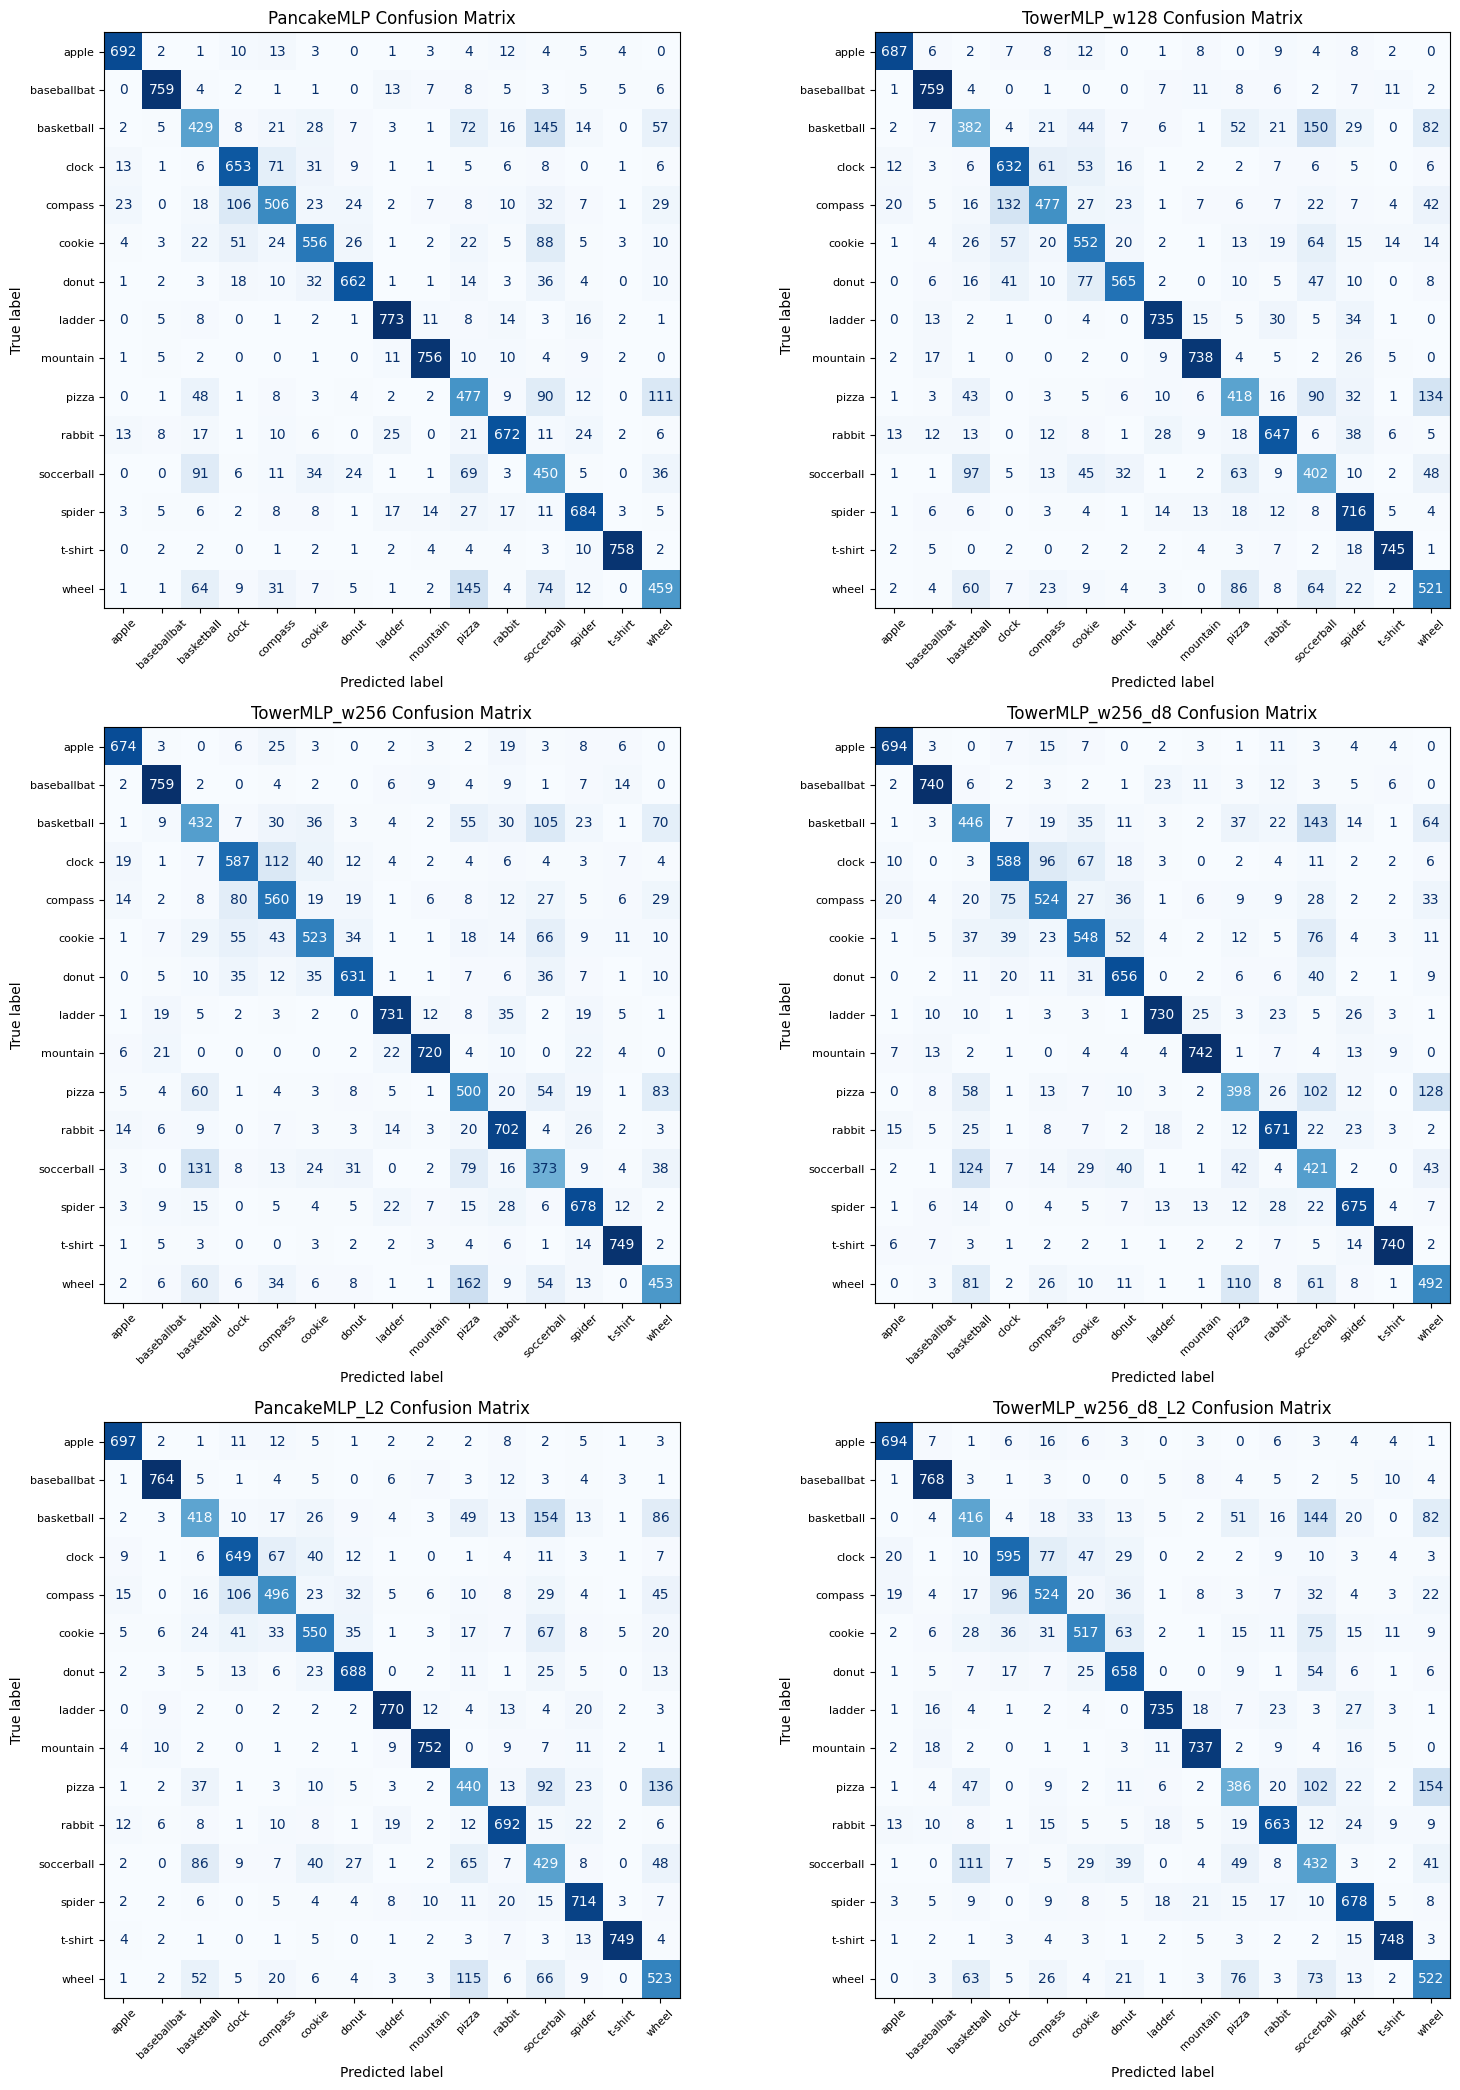


Comparison table (all models):


,Model,Params,Params (M),Best Epoch,Best Train Acc,Best Val Acc,Final Train Acc,Final Val Acc,Generalization Gap,Final Val Loss,Val Acc / MParam,Weight Decay,Best Model File
0,PancakeMLP_L2,2933775,2.9338,33,0.9991,0.7776,0.9988,0.7753,0.2235,1.0462,0.2650,0.0010,./checkpoints/best_pancake_l2.pth
1,PancakeMLP,2933775,2.9338,39,0.9988,0.7738,0.9988,0.7722,0.2265,1.0365,0.2638,0.0001,./checkpoints/best_pancake.pth
2,TowerMLP_w256_d8_L2,669455,0.6695,8,0.9796,0.7561,0.9794,0.7528,0.2266,1.2173,1.1294,0.0010,./checkpoints/best_tower_w256_d8_l2.pth
3,TowerMLP_w256,536847,0.5368,4,0.9868,0.7560,0.9861,0.7522,0.2339,1.2433,1.4082,0.0001,./checkpoints/best_tower_w256.pth
4,TowerMLP_w256_d8,669455,0.6695,8,0.9800,0.7554,0.9800,0.7532,0.2268,1.2312,1.1284,0.0001,./checkpoints/best_tower_w256_d8.pth
5,TowerMLP_w128,186511,0.1865,5,0.9670,0.7480,0.9652,0.7358,0.2294,1.2826,4.0105,0.0001,./checkpoints/best_tower.pth


Saved comparison table: ./comparison/baseline_comparison_table.csv

Analysis (Part A vs Part B):
- Part A (PancakeMLP, wide shallow) best val acc = 0.7738.
- Part B best variant = TowerMLP_w256_d8_L2 with best val acc = 0.7561, params = 669,455.
- Highest parameter-efficiency (best val acc per million params) = TowerMLP_w128 (4.0105).
- Train vs validation gaps indicate overfitting in all models; use the reported gaps in your write-up.


In [18]:
# ==========================================
# MODEL COMPARISON + ANALYSIS
# ==========================================

import pandas as pd
from IPython.display import display, Markdown

comparison_dir = globals().get("COMPARISON_DIR", "./comparison")
os.makedirs(comparison_dir, exist_ok=True)

required_results = {
    "PancakeMLP": "pancake_results",
    "TowerMLP_w128": "tower_results",
}
optional_results = {
    "TowerMLP_w256": "tower_256_results",
    "TowerMLP_w256_d8": "tower_256_d8_results",
    "PancakeMLP_L2": "pancake_l2_results",
    "TowerMLP_w256_d8_L2": "tower_256_d8_l2_results",
}

model_results = {}
for model_name, result_name in required_results.items():
    if result_name not in globals():
        raise RuntimeError(f"Run {model_name} cell first.")
    model_results[model_name] = globals()[result_name]

for model_name, result_name in optional_results.items():
    if result_name in globals():
        model_results[model_name] = globals()[result_name]
    else:
        print(f"Skipping {model_name} (run cell first to include).")

for model_name, results in model_results.items():
    if "diagnostics" not in results:
        raise RuntimeError(f"Diagnostics missing for {model_name}. Re-run its model cell.")
    required_keys = {"cm", "class_acc"}
    missing = required_keys - set(results["diagnostics"].keys())
    if missing:
        raise RuntimeError(f"Diagnostics keys missing for {model_name}: {missing}. Re-run its model cell.")

comparison = []
for model_name, results in model_results.items():
    history = results["history"]
    best_train_acc = float(np.max(history["train_acc"]))
    best_val_acc = history["best_val_acc"]
    params_m = results["params"] / 1_000_000
    comparison.append(
        {
            "Model": model_name,
            "Params": results["params"],
            "Best Train Acc": best_train_acc,
            "Best Val Acc": best_val_acc,
            "Best Epoch": history["best_epoch"],
            "Final Train Acc": history["train_acc"][-1],
            "Final Val Acc": history["val_acc"][-1],
            "Final Val Loss": history["val_loss"][-1],
            "Val Acc / MParam": best_val_acc / params_m,
            "Weight Decay": results.get("weight_decay", np.nan),
            "Best Model File": results.get("checkpoint", ""),
        }
    )

comparison_sorted = sorted(comparison, key=lambda row: row["Best Val Acc"], reverse=True)

print("Model comparison summary (Training vs Validation):")
for row in comparison_sorted:
    acc_gap = row["Final Train Acc"] - row["Final Val Acc"]
    print(
        f"{row['Model']:18s} | "
        f"Params: {row['Params']:>9,} | "
        f"Best Train/Val: {row['Best Train Acc']:.4f}/{row['Best Val Acc']:.4f} (best ep {row['Best Epoch']}) | "
        f"Final Train/Val: {row['Final Train Acc']:.4f}/{row['Final Val Acc']:.4f} | "
        f"Generalization Gap: {acc_gap:+.4f} | "
        f"Val Acc/MParam: {row['Val Acc / MParam']:.4f} | "
        f"Final Val Loss: {row['Final Val Loss']:.4f}"
    )

if len(comparison_sorted) >= 2:
    winner = comparison_sorted[0]["Model"]
    runner_up = comparison_sorted[1]["Model"]
    margin = comparison_sorted[0]["Best Val Acc"] - comparison_sorted[1]["Best Val Acc"]
    print(f"\nWinner by best validation accuracy: {winner} over {runner_up} (margin = {margin:.4f})")

models = [row["Model"] for row in comparison_sorted]
best_val_acc = [row["Best Val Acc"] for row in comparison_sorted]
params_millions = [row["Params"] / 1_000_000 for row in comparison_sorted]
plot_colors = [plt.cm.tab10(i) for i in range(len(comparison_sorted))]
positions = np.arange(len(models))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].bar(positions, best_val_acc, color=plot_colors)
axes[0].set_title("Best Validation Accuracy")
axes[0].set_xticks(positions)
axes[0].set_xticklabels(models, rotation=35, ha="right")
axes[0].set_ylim(min(best_val_acc) - 0.01, max(best_val_acc) + 0.015)
for index, value in enumerate(best_val_acc):
    axes[0].text(index, value + 0.001, f"{value:.4f}", ha="center", va="bottom", fontsize=9)

axes[1].bar(positions, params_millions, color=plot_colors)
axes[1].set_title("Trainable Parameters (Millions)")
axes[1].set_xticks(positions)
axes[1].set_xticklabels(models, rotation=35, ha="right")
for index, value in enumerate(params_millions):
    axes[1].text(index, value + 0.01, f"{value:.3f}M", ha="center", va="bottom", fontsize=9)

fig.subplots_adjust(bottom=0.28, wspace=0.25)
bestval_params_plot = os.path.join(comparison_dir, "baseline_bestval_vs_params.png")
fig.savefig(bestval_params_plot, bbox_inches="tight")
print(f"Saved plot: {bestval_params_plot}")
plt.show()

# ------------------------------
# Class distribution (total data)
# ------------------------------
if not hasattr(full_train_dataset, "y") or full_train_dataset.y is None:
    raise RuntimeError("full_train_dataset does not contain labels needed for total class distribution.")

total_labels = full_train_dataset.y.cpu().numpy() if torch.is_tensor(full_train_dataset.y) else np.asarray(full_train_dataset.y)
class_counts = np.bincount(total_labels.astype(int), minlength=len(CLASSES))
class_percent = 100.0 * class_counts / class_counts.sum()

print(f"\nTotal labeled samples used for class distribution: {class_counts.sum()}")

x = np.arange(len(CLASSES))
plt.figure(figsize=(15, 5))
plt.bar(x, class_counts, color="tab:purple", alpha=0.9)
plt.xticks(x, CLASSES, rotation=45, ha="right")
plt.ylabel("Number of Samples")
plt.title("Total Data Class Distribution")
plt.grid(axis="y", alpha=0.3)

for idx, (count, pct) in enumerate(zip(class_counts, class_percent)):
    plt.text(idx, count + max(class_counts) * 0.01, f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
class_distribution_plot = os.path.join(comparison_dir, "baseline_class_distribution.png")
plt.savefig(class_distribution_plot, bbox_inches="tight")
print(f"Saved plot: {class_distribution_plot}")
plt.show()

# ------------------------------
# Class-wise accuracy comparison
# ------------------------------
class_acc_dict = {
    name: np.asarray(results["diagnostics"]["class_acc"])
    for name, results in model_results.items()
}

x = np.arange(len(CLASSES))
num_models = len(class_acc_dict)
bar_width = 0.8 / num_models
offset_start = -0.4 + bar_width / 2

plt.figure(figsize=(18, 6))
for model_index, (name, acc_values) in enumerate(class_acc_dict.items()):
    positions = x + offset_start + model_index * bar_width
    plt.bar(positions, acc_values, width=bar_width, label=name, alpha=0.9, color=plot_colors[model_index])

plt.xticks(x, CLASSES, rotation=45, ha="right")
plt.ylabel("Class-wise Accuracy")
plt.title("Class-wise Accuracy Comparison")
plt.ylim(0.0, 1.0)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
classwise_plot = os.path.join(comparison_dir, "baseline_classwise_accuracy.png")
plt.savefig(classwise_plot, bbox_inches="tight")
print(f"Saved plot: {classwise_plot}")
plt.show()

print("\nClass-wise accuracy delta vs PancakeMLP:")
pancake_class_acc = class_acc_dict["PancakeMLP"]
for model_name in [name for name in class_acc_dict.keys() if name != "PancakeMLP"]:
    class_delta = class_acc_dict[model_name] - pancake_class_acc
    print(f"\n{model_name} - PancakeMLP")
    for class_index in np.argsort(class_delta):
        print(f"{CLASSES[class_index]:15s} : {class_delta[class_index]:+0.3f}")

# ------------------------------
# Confusion matrix comparison (2 per row)
# ------------------------------
num_models = len(model_results)
ncols = 2
nrows = int(np.ceil(num_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 7 * nrows))
axes = np.array(axes).reshape(-1)

for axis, (name, results) in zip(axes, model_results.items()):
    cm = np.asarray(results["diagnostics"]["cm"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(ax=axis, cmap="Blues", xticks_rotation=45, values_format="d", colorbar=False)
    axis.set_title(f"{name} Confusion Matrix", fontsize=12)
    axis.tick_params(axis="x", labelsize=8)
    axis.tick_params(axis="y", labelsize=8)

for axis in axes[num_models:]:
    axis.axis("off")

plt.tight_layout()
confusion_plot = os.path.join(comparison_dir, "baseline_confusion_matrices.png")
plt.savefig(confusion_plot, bbox_inches="tight")
print(f"Saved plot: {confusion_plot}")
plt.show()

# ------------------------------
# Comparison table (all models)
# ------------------------------
comparison_table = pd.DataFrame(comparison_sorted).copy()
comparison_table["Params (M)"] = comparison_table["Params"] / 1_000_000
comparison_table["Generalization Gap"] = comparison_table["Final Train Acc"] - comparison_table["Final Val Acc"]
comparison_table = comparison_table[[
    "Model",
    "Params",
    "Params (M)",
    "Best Epoch",
    "Best Train Acc",
    "Best Val Acc",
    "Final Train Acc",
    "Final Val Acc",
    "Generalization Gap",
    "Final Val Loss",
    "Val Acc / MParam",
    "Weight Decay",
    "Best Model File",
]]

print("\nComparison table (all models):")
display(comparison_table.round(4))
comparison_csv_path = os.path.join(comparison_dir, "baseline_comparison_table.csv")
comparison_table.round(6).to_csv(comparison_csv_path, index=False)
print(f"Saved comparison table: {comparison_csv_path}")

# ------------------------------
# Analysis summary (for report)
# ------------------------------
best_tower = max(
    [row for row in comparison if row["Model"].startswith("TowerMLP")],
    key=lambda row: row["Best Val Acc"],
)
pancake_best_val = next(row["Best Val Acc"] for row in comparison if row["Model"] == "PancakeMLP")
best_eff_model = max(comparison, key=lambda row: row["Val Acc / MParam"])

print("\nAnalysis (Part A vs Part B):")
print(f"- Part A (PancakeMLP, wide shallow) best val acc = {pancake_best_val:.4f}.")
print(
    f"- Part B best variant = {best_tower['Model']} with best val acc = {best_tower['Best Val Acc']:.4f}, "
    f"params = {best_tower['Params']:,}."
)
print(
    f"- Highest parameter-efficiency (best val acc per million params) = {best_eff_model['Model']} "
    f"({best_eff_model['Val Acc / MParam']:.4f})."
)
print("- Train vs validation gaps indicate overfitting in all models; use the reported gaps in your write-up.")

best_overall = comparison_sorted[0]
analysis_md = f"""## Final Comparison Analysis (Auto-generated)
- **Best overall validation accuracy:** {best_overall['Model']} ({best_overall['Best Val Acc']:.4f})
- **Best Tower variant:** {best_tower['Model']} ({best_tower['Best Val Acc']:.4f})
- **Best parameter-efficiency:** {best_eff_model['Model']} ({best_eff_model['Val Acc / MParam']:.4f} val acc / M param)
"""


In [17]:
# ==========================================
# TEST INFERENCE + SUBMISSION EXPORT (ALL MODELS)
# ==========================================
import re

result_candidates = {
    "PancakeMLP": globals().get("pancake_results"),
    "TowerMLP_w128": globals().get("tower_results"),
    "TowerMLP_w256": globals().get("tower_256_results"),
    "TowerMLP_w256_d8": globals().get("tower_256_d8_results"),
    "PancakeMLP_L2": globals().get("pancake_l2_results"),
    "TowerMLP_w256_d8_L2": globals().get("tower_256_d8_l2_results"),
}

available_results = {
    name: result
    for name, result in result_candidates.items()
    if isinstance(result, dict) and "model" in result and "history" in result
}

if not available_results:
    raise RuntimeError("No trained model results found. Run model training cells first.")

results_dir = globals().get("RESULTS_DIR", "./results")
os.makedirs(results_dir, exist_ok=True)


def sanitize_model_name(model_name):
    return re.sub(r"[^0-9A-Za-z_]+", "_", model_name)


@torch.no_grad()
def run_test_inference(model, test_loader):
    model.eval()
    all_test_preds = []

    for batch in test_loader:
        images = batch[0] if isinstance(batch, (tuple, list)) else batch
        images = normalize_batch(images).to(DEVICE)
        logits = model(images)
        preds = torch.argmax(logits, dim=1)
        all_test_preds.append(preds.cpu().numpy())

    return np.concatenate(all_test_preds).astype(int)


print(f"Loading test data from {TEST_FILE}...")
test_dataset = QuickDrawDataset(TEST_FILE, mode="test")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

exported_files = {}
for model_name, result in available_results.items():
    model = result["model"]

    checkpoint_path = result.get("checkpoint", "")
    if checkpoint_path and os.path.exists(checkpoint_path):
        state_dict = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(state_dict)
        print(f"[{model_name}] Loaded checkpoint: {checkpoint_path}")
    else:
        print(f"[{model_name}] Checkpoint not found; using in-memory model weights.")

    test_preds = run_test_inference(model, test_loader)

    safe_name = sanitize_model_name(model_name)
    output_file = os.path.join(results_dir, f"submission_{safe_name}.txt")
    with open(output_file, "w") as f:
        f.write(",".join(map(str, test_preds.tolist())))

    exported_files[model_name] = output_file
    print(f"[{model_name}] Exported {len(test_preds)} predictions -> {output_file}")

if "comparison_sorted" in globals() and comparison_sorted:
    best_model_name = comparison_sorted[0]["Model"]
else:
    best_model_name = max(
        available_results.keys(),
        key=lambda name: available_results[name]["history"].get(
            "best_val_acc",
            float(np.max(available_results[name]["history"]["val_acc"])),
        ),
    )

best_output_file = exported_files.get(best_model_name)
if best_output_file and os.path.exists(best_output_file):
    final_submission_file = os.path.join(results_dir, "submission.txt")
    with open(best_output_file, "r") as src, open(final_submission_file, "w") as dst:
        dst.write(src.read())
    print(f"\nUpdated {final_submission_file} from best model: {best_model_name}")

print("\nAll exported files:")
for model_name, file_name in exported_files.items():
    print(f"- {model_name}: {file_name}")

Loading test data from ./processed_data/quickdraw_test.npz...
Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.
[PancakeMLP] Loaded checkpoint: ./checkpoints/best_pancake.pth
[PancakeMLP] Exported 15000 predictions -> ./results/submission_PancakeMLP.txt
[TowerMLP_w128] Loaded checkpoint: ./checkpoints/best_tower.pth
[TowerMLP_w128] Exported 15000 predictions -> ./results/submission_TowerMLP_w128.txt
[TowerMLP_w256] Loaded checkpoint: ./checkpoints/best_tower_w256.pth
[TowerMLP_w256] Exported 15000 predictions -> ./results/submission_TowerMLP_w256.txt
[TowerMLP_w256_d8] Loaded checkpoint: ./checkpoints/best_tower_w256_d8.pth
[TowerMLP_w256_d8] Exported 15000 predictions -> ./results/submission_TowerMLP_w256_d8.txt
[PancakeMLP_L2] Loaded checkpoint: ./checkpoints/best_pancake_l2.pth
[PancakeMLP_L2] Exported 15000 predictions -> ./results/submission_PancakeMLP_L2.txt
[TowerMLP_w256_d8_L2] Loaded checkpoint: ./checkpoints/best_tower_w256_d8_l2.pth
[Tow